# ITB Consumer Wellbeing & Segmentation (BI10 Round 01)
Team YAPPERS

This notebook contains the full analysis behind our slide deck: data checks, Task 1 (EDA), Task 2 (financial health), Task 3 (engagement), Task 4 (segmentation) and Task 5 (recommendations).

Two principles apply throughout:
- This is a wellbeing study, not credit scoring. `financial_health_score` is never used to deny credit, cut a limit or block an account.
- Income, credit limit and balances are synthetic and inflated, so we compare customers on ratios and shares rather than absolute VND.

To run: `Runtime → Run all` in Google Colab (about 3–4 minutes). The data is downloaded from a public Google Drive folder; no extra packages are needed.

## 0. Setup and data loading

In [1]:
import os, gzip, shutil, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

In [2]:
DATA_DIR = "BI10_ROUND01_DATASET"
if not os.path.exists(DATA_DIR) and os.path.exists(os.path.join("..", DATA_DIR)):
    os.chdir("..")  # running locally from the notebooks/ folder

MONTHLY = f"{DATA_DIR}/consumer_financial_health_engagement_2025.csv"
TXN = f"{DATA_DIR}/consumer_transactions_2025.parquet/consumer_transactions_2025.csv"
# public Google Drive files (the ".parquet.gz" file is actually the gzipped transactions CSV)
DRIVE_ID = {"monthly": "1YyueAH9Kasid6V_obml9pCMwh2dB0ryn", "transactions_gz": "1O33KpFbUx6_BRGwFTb80xVSB3tzXqt5H"}

def download(file_id, dest, tries=3):
    url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    for attempt in range(tries):
        try:
            urllib.request.urlretrieve(url, dest + ".part")
            os.replace(dest + ".part", dest)
            return
        except Exception as e:
            print(f"download failed ({e}), retrying...")
    raise RuntimeError(f"could not download {dest}")

if not os.path.exists(MONTHLY):
    download(DRIVE_ID["monthly"], MONTHLY)
if not os.path.exists(TXN):
    download(DRIVE_ID["transactions_gz"], TXN + ".gz")
    with gzip.open(TXN + ".gz") as src, open(TXN + ".part", "wb") as dst:
        shutil.copyfileobj(src, dst)
    os.replace(TXN + ".part", TXN)

In [3]:
mon = pd.read_csv(MONTHLY, parse_dates=["analysis_month"])
mon["month"] = mon["analysis_month"].dt.month
txn = pd.read_csv(TXN, usecols=["transaction_id", "consumer_id", "merchant_id", "activity_datetime", "spend_amount_vnd",
                                "spending_category", "province_city", "transaction_channel", "transaction_month",
                                "transaction_day_of_week", "transaction_hour", "essential_spending_flag"])
print(f"monthly file: {len(mon):,} consumer-months, {mon.consumer_id.nunique()} consumers")
print(f"transactions: {len(txn):,} rows")

monthly file: 10,992 consumer-months, 999 consumers
transactions: 1,852,394 rows


## 1. Data quality checks
Before the analysis we check completeness, duplicates, consistency between the two files and value ranges.

In [4]:
names = pd.read_csv(TXN, usecols=["consumer_id", "customer_name", "date_of_birth", "merchant_id", "merchant_name"])
ts = pd.to_datetime(txn["activity_datetime"])
recon = (txn.groupby(["consumer_id", "transaction_month"])["spend_amount_vnd"].sum().rename("txn_sum").reset_index()
         .merge(mon[["consumer_id", "month", "total_spend_vnd"]], left_on=["consumer_id", "transaction_month"],
                right_on=["consumer_id", "month"], how="outer"))
ratio_cols = ["essential_spend_ratio", "discretionary_spend_ratio", "online_spend_ratio", "credit_utilization_ratio"]

checks = pd.Series({
    "missing cells (transactions)": txn.isna().sum().sum(),
    "missing cells (monthly, excl. next_month_low_health_flag)": mon.drop(columns="next_month_low_health_flag").isna().sum().sum(),
    "duplicate transaction_id": txn["transaction_id"].duplicated().sum(),
    "duplicate consumer-month rows": mon.duplicated(["consumer_id", "month"]).sum(),
    "negative spend_amount_vnd": (txn["spend_amount_vnd"] < 0).sum(),
    "timestamps outside 2025": (ts.dt.year != 2025).sum(),
    "consumers with >1 name or birth date": (names.groupby("consumer_id")[["customer_name", "date_of_birth"]].nunique() > 1).any(axis=1).sum(),
    "merchants with >1 name": (names.groupby("merchant_id")["merchant_name"].nunique() > 1).sum(),
    "consumer_id in only one file": len(set(txn.consumer_id) ^ set(mon.consumer_id)),
    "consumer-months where transactions != total_spend_vnd": (recon["txn_sum"].fillna(-1) != recon["total_spend_vnd"].fillna(-2)).sum(),
    "ratio values outside [0, 1]": sum(((mon[c] < 0) | (mon[c] > 1)).sum() for c in ratio_cols),
})
del names
print(checks.to_string())
print(f"\n{txn.consumer_id.nunique()} consumers, {txn.merchant_id.nunique()} merchants, {txn.province_city.nunique()} provinces")
print(f"{len(mon):,} of {999 * 12:,} possible consumer-months present; months per consumer: "
      f"{mon.groupby('consumer_id').size().min()}-{mon.groupby('consumer_id').size().max()}")
print("next_month_low_health_flag is empty for December by design:", mon["next_month_low_health_flag"].isna().sum())
out_of_range = mon[(mon.credit_utilization_ratio > 1)]
print("\nRatios above 1 are credit utilization in over-limit months:")
print(out_of_range[["consumer_id", "month", "credit_utilization_ratio", "financial_health_score"]].to_string(index=False))

missing cells (transactions)                                 0
missing cells (monthly, excl. next_month_low_health_flag)    0
duplicate transaction_id                                     0
duplicate consumer-month rows                                0
negative spend_amount_vnd                                    0
timestamps outside 2025                                      0
consumers with >1 name or birth date                         0
merchants with >1 name                                       0
consumer_id in only one file                                 0
consumer-months where transactions != total_spend_vnd        0
ratio values outside [0, 1]                                  5



999 consumers, 693 merchants, 34 provinces
10,992 of 11,988 possible consumer-months present; months per consumer: 1-12
next_month_low_health_flag is empty for December by design: 999

Ratios above 1 are credit utilization in over-limit months:
consumer_id  month  credit_utilization_ratio  financial_health_score
 KH00103525      9                    1.5000                     0.8
 KH00104130      7                    1.1065                    34.5
 KH00114685     12                    1.0312                    12.8
 KH00119525     12                    1.0560                     1.4
 KH00119565      7                    1.3095                     1.1


The data is clean. The five out-of-range values are over-limit months (utilization 1.03–1.5), all with very low health, so we keep them as real behaviour.

Caveat from the case study (section 12): two source years were folded onto 2025. Timestamps were re-dated so all fall in 2025, but monthly volumes are higher than a single real year. We treat absolute volumes as directional and rely on ratios.

## Task 1: Exploratory Data Analysis
### Q1. Peak vs trough month: is the peak driven by count or ticket size?

In [5]:
by_month = txn.groupby("transaction_month")["spend_amount_vnd"].agg(total="sum", count="count")
by_month["avg_ticket"] = by_month["total"] / by_month["count"]
by_month["pct_of_year"] = 100 * by_month["total"] / by_month["total"].sum()
peak, trough = by_month["total"].idxmax(), by_month["total"].idxmin()
p, t = by_month.loc[peak], by_month.loc[trough]
print(by_month.assign(total_bn=by_month.total / 1e9).drop(columns="total").round(2).to_string())
print(f"\nAnnual spend: {by_month.total.sum() / 1e12:.2f}T VND")
print(f"Peak month {peak}: {p.total / 1e9:.2f}B VND ({p.pct_of_year:.2f}% of year) | trough month {trough}: "
      f"{t.total / 1e9:.2f}B VND ({t.pct_of_year:.2f}%) | ratio {p.total / t.total:.1f}x")
print(f"Transaction count {100 * (p['count'] / t['count'] - 1):+.0f}%, average ticket {100 * (p.avg_ticket / t.avg_ticket - 1):+.1f}%")
active = txn.groupby("transaction_month").consumer_id.nunique()
print(f"Active consumers: month {trough} {active[trough]}, month {peak} {active[peak]} | transactions per active consumer "
      f"{t['count'] / active[trough]:.0f} -> {p['count'] / active[peak]:.0f}")

                    count  avg_ticket  pct_of_year  total_bn
transaction_month                                           
1                  104727  1771944.51         5.72    185.57
2                   97657  1785485.02         5.37    174.37
3                  143789  1771693.27         7.85    254.75
4                  134970  1750914.53         7.28    236.32
5                  146875  1754031.96         7.94    257.62
6                  173869  1757489.21         9.42    305.57
7                  172444  1737120.53         9.23    299.56
8                  176118  1729062.81         9.39    304.52
9                  140185  1758539.53         7.60    246.52
10                 138106  1759558.88         7.49    243.01
11                 143056  1739149.93         7.67    248.80
12                 280598  1739259.40        15.04    488.03

Annual spend: 3.24T VND
Peak month 12: 488.03B VND (15.04% of year) | trough month 2: 174.37B VND (5.37%) | ratio 2.8x
Transaction count +187%, a

In [6]:
cat_month = txn.groupby(["transaction_month", "spending_category"]).size().unstack()
growth = (100 * (cat_month.loc[peak] / cat_month.loc[trough] - 1)).sort_values()
print(f"Growth in transaction count, month {peak} vs month {trough}, by category:")
print(growth.round(0).to_string())

Growth in transaction count, month 12 vs month 2, by category:
spending_category
Siêu thị và tạp hóa tại cửa hàng    181.0
Ăn uống                             182.0
Tạp hóa trực tuyến                  183.0
Sức khỏe và thể thao                184.0
Mua sắm tại cửa hàng                186.0
Xăng dầu và di chuyển               187.0
Trẻ em và thú cưng                  187.0
Du lịch                             188.0
Mua sắm trực tuyến                  189.0
Chăm sóc cá nhân                    190.0
Giải trí                            191.0
Dịch vụ trực tuyến khác             191.0
Mua sắm khác tại cửa hàng           192.0
Nhà cửa và tiện ích                 193.0


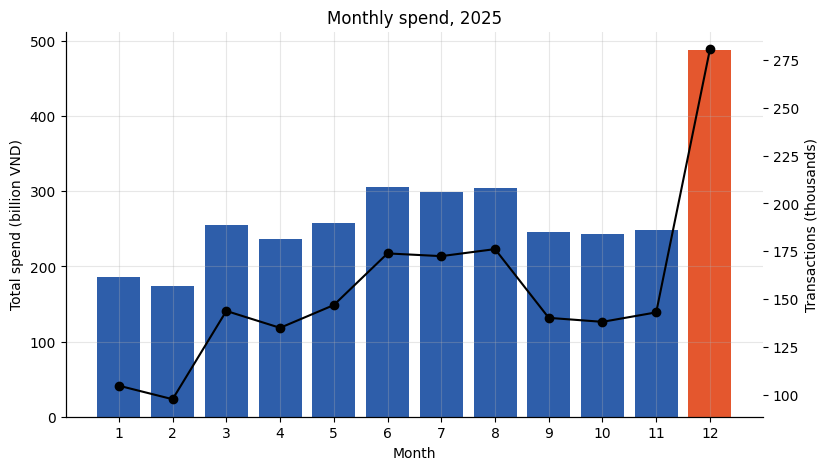

In [7]:
fig, ax = plt.subplots()
ax.bar(by_month.index, by_month.total / 1e9, color=["#E4572E" if m == peak else "#2E5EAA" for m in by_month.index])
ax.set(xlabel="Month", ylabel="Total spend (billion VND)", title="Monthly spend, 2025", xticks=range(1, 13))
ax2 = ax.twinx()
ax2.plot(by_month.index, by_month["count"] / 1e3, color="black", marker="o")
ax2.set_ylabel("Transactions (thousands)")
ax2.grid(False)
plt.show()

December is the peak (15.04% of annual spend, 2.8× February). The increase comes from more transactions (+187%), while the average ticket slightly falls (−2.6%). The same customers are active (919 vs 918) but transact almost three times as often, and every category grows by a similar amount (+181% to +193%). December is also the weakest month for financial health (Task 2). The two-year fold inflates absolute VND in every month, so the share and the ratio are the reliable part.

### Q2. Essential vs discretionary spend: stressed vs healthy customers

In [8]:
def mix(df):
    ess, disc = df["essential_spend_vnd"].sum(), df["discretionary_spend_vnd"].sum()
    return pd.Series({"consumer_months": len(df), "consumers": df.consumer_id.nunique(),
                      "essential_%": 100 * ess / (ess + disc), "discretionary_%": 100 * disc / (ess + disc)})

stressed = mon[mon.financial_health_score < 40]
healthy = mon[mon.financial_health_score >= 80]
print(pd.DataFrame({"stressed (FHS<40)": mix(stressed), "healthy (FHS>=80)": mix(healthy)}).round(1).to_string())

                 stressed (FHS<40)  healthy (FHS>=80)
consumer_months               95.0              475.0
consumers                     70.0              303.0
essential_%                   28.4               59.5
discretionary_%               71.6               40.5


                        consumer_months  discretionary_%
financial_health_score                                  
<40                                95.0             71.6
40-49                             429.0             64.2
50-59                            2028.0             57.3
60-69                            4060.0             54.4
70-79                            3905.0             49.2
80-89                             474.0             40.6
90+                                 1.0             17.4
FHS<35 vs FHS>=85: discretionary 73.5% vs 30.2%
FHS<45 vs FHS>=75: discretionary 68.7% vs 45.6%
FHS<50 vs FHS>=70: discretionary 65.4% vs 48.7%


stressed: essential share of transactions 46.3% | discretionary avg ticket 3.9M VND | purchases >= 10M: 4.3% of transactions, 54% of value
healthy: essential share of transactions 47.8% | discretionary avg ticket 1.1M VND | purchases >= 10M: 0.4% of transactions, 3% of value


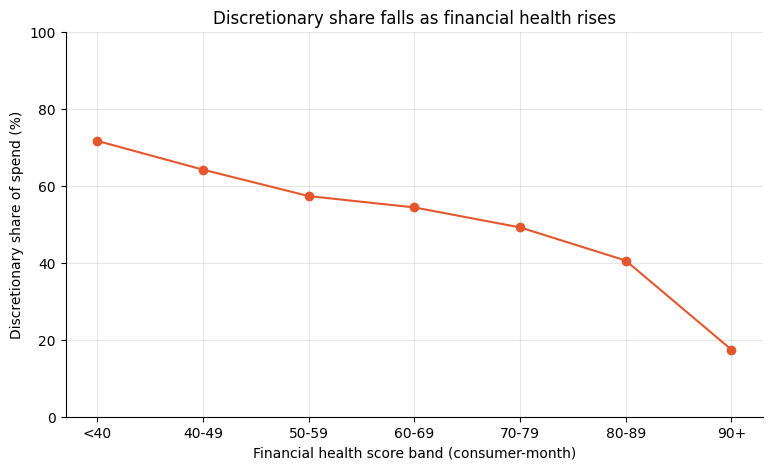

In [9]:
# is it a gradient or only visible at the two extremes?
bands = pd.cut(mon.financial_health_score, [0, 40, 50, 60, 70, 80, 90, 101], right=False,
               labels=["<40", "40-49", "50-59", "60-69", "70-79", "80-89", "90+"])
gradient = mon.groupby(bands, observed=True).apply(mix, include_groups=False)
print(gradient[["consumer_months", "discretionary_%"]].round(1).to_string())
for lo, hi in [(35, 85), (45, 75), (50, 70)]:
    print(f"FHS<{lo} vs FHS>={hi}: discretionary {mix(mon[mon.financial_health_score < lo])['discretionary_%']:.1f}% "
          f"vs {mix(mon[mon.financial_health_score >= hi])['discretionary_%']:.1f}%")

# where does the flip come from: more discretionary purchases, or bigger ones?
tm = txn.merge(mon[["consumer_id", "month", "financial_health_score"]], left_on=["consumer_id", "transaction_month"],
               right_on=["consumer_id", "month"])
for name, d in [("stressed", tm[tm.financial_health_score < 40]), ("healthy", tm[tm.financial_health_score >= 80])]:
    ess = d.essential_spending_flag.astype(bool)
    big = d.spend_amount_vnd >= 10e6
    print(f"{name}: essential share of transactions {100 * ess.mean():.1f}% | discretionary avg ticket "
          f"{d.loc[~ess, 'spend_amount_vnd'].mean() / 1e6:.1f}M VND | purchases >= 10M: {100 * big.mean():.1f}% of transactions, "
          f"{100 * d.loc[big, 'spend_amount_vnd'].sum() / d.spend_amount_vnd.sum():.0f}% of value")

fig, ax = plt.subplots()
ax.plot(gradient.index.astype(str), gradient["discretionary_%"], marker="o", color="#E4572E")
ax.set(xlabel="Financial health score band (consumer-month)", ylabel="Discretionary share of spend (%)",
       title="Discretionary share falls as financial health rises", ylim=(0, 100))
plt.show()

Under stress the budget flips: stressed months are 28% essential / 72% discretionary, healthy months 60% / 40%. The share falls steadily across health bands, and every alternative cutoff gives the same direction, so this is not an artefact of the 40/80 thresholds. The flip is in value rather than habits: essentials are a similar share of transactions in both groups, but stressed months contain a few very large discretionary purchases (≥ 10M VND: about 4% of transactions but over half of the value). This points to pre-purchase visibility rather than restriction.

### Q3. High-spend provinces with below-average digital share

In [10]:
txn["digital"] = txn["transaction_channel"] != "POS"
prov = txn.groupby("province_city").agg(total_spend=("spend_amount_vnd", "sum"), txns=("digital", "size"), digital=("digital", "mean"))
prov["digital_%"] = 100 * prov["digital"]
national_digital = 100 * txn["digital"].mean()
gap_provinces = (prov[(prov.total_spend > prov.total_spend.median()) & (prov["digital_%"] < national_digital)]
                 .sort_values("total_spend", ascending=False))
print(f"National digital share of transactions: {national_digital:.1f}%")
prov["spend_%"] = 100 * prov.total_spend / prov.total_spend.sum()
print("Top by spend:", prov["spend_%"].idxmax(), round(prov["spend_%"].max(), 1), "% of spend,", round(prov.loc[prov["spend_%"].idxmax(), "digital_%"], 1), "% digital")
print(f"Digital share range across {len(prov)} provinces: {prov['digital_%'].min():.1f}% ({prov['digital_%'].idxmin()}) to {prov['digital_%'].max():.1f}% ({prov['digital_%'].idxmax()})")
print(gap_provinces.assign(total_spend_bn=gap_provinces.total_spend / 1e9)[["total_spend_bn", "digital_%"]].round(2).to_string())

National digital share of transactions: 41.2%
Top by spend: Thành phố Hồ Chí Minh 13.6 % of spend, 41.3 % digital
Digital share range across 34 provinces: 39.2% (Quảng Ngãi) to 43.1% (Cao Bằng)
               total_spend_bn  digital_%
province_city                           
Hà Nội                 267.26      40.88
Đồng Nai               183.07      40.73
Lâm Đồng               135.39      41.10
Hưng Yên               116.44      40.78
Hải Phòng              103.15      40.85
Nghệ An                101.73      41.15


Share of transactions by channel (%)
 transaction_channel   POS  QR Payment  E-commerce  Mobile App  Recurring Payment
province_city                                                                   
Hà Nội               59.1        19.9         8.5         7.6                4.9
Hưng Yên             59.2        19.8         8.4         7.4                5.1
Hải Phòng            59.2        20.1         8.5         7.4                4.9
Lâm Đồng             58.9        19.7         8.7         7.6                5.1
Nghệ An              58.8        20.3         8.5         7.7                4.7
Đồng Nai             59.3        19.8         8.5         7.6                4.8
National             58.8        19.8         8.7         7.7                4.9

Share of spend value by channel (%)
 transaction_channel   POS  QR Payment  E-commerce  Mobile App  Recurring Payment
province_city                                                                   
Hà Nội               59.1        

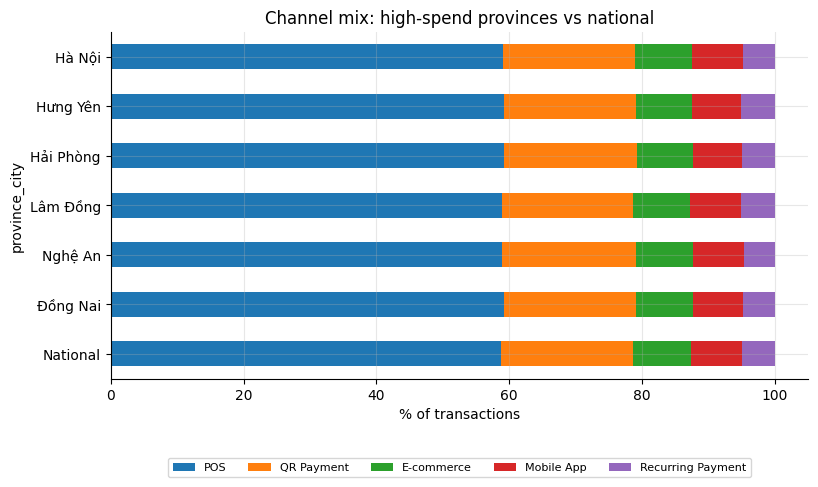

In [11]:
channels = ["POS", "QR Payment", "E-commerce", "Mobile App", "Recurring Payment"]
qualifying = gap_provinces.index.tolist()
sub = txn[txn.province_city.isin(qualifying)]
by_count = pd.crosstab(sub.province_city, sub.transaction_channel, normalize="index")[channels] * 100
by_value = pd.crosstab(sub.province_city, sub.transaction_channel, values=sub.spend_amount_vnd, aggfunc="sum", normalize="index")[channels] * 100
by_count.loc["National"] = txn.transaction_channel.value_counts(normalize=True)[channels] * 100
by_value.loc["National"] = txn.groupby("transaction_channel").spend_amount_vnd.sum()[channels] / txn.spend_amount_vnd.sum() * 100
print("Share of transactions by channel (%)\n", by_count.round(1).to_string())
print("\nShare of spend value by channel (%)\n", by_value.round(1).to_string())
gap = by_count.drop("National")[channels[1:]].sum(axis=1) - by_count.loc["National", channels[1:]].sum()
print("\nDigital gap vs national (pp):", gap.round(2).to_dict())

by_count.plot.barh(stacked=True, figsize=(9, 4.5), title="Channel mix: high-spend provinces vs national")
plt.gca().invert_yaxis(); plt.xlabel("% of transactions"); plt.legend(ncol=5, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.3))
plt.show()

Ho Chi Minh City is the top market (13.6% of spend) with a digital share at the national level, and all 34 provinces fall between 39.2% and 43.1% digital. Six high-spend provinces (Ha Noi, Dong Nai, Lam Dong, Hung Yen, Hai Phong, Nghe An) sit below the national digital share, but only by 0.03–0.46 percentage points; they trail slightly on e-commerce and mobile app while QR is at par, and their channel mix by count and by value is almost identical to the national mix. There is no meaningful regional digital gap, so province is not a useful lever for digital adoption.

### Q4. Top category by transaction count vs by spend

In [12]:
cat = txn.groupby("spending_category")["spend_amount_vnd"].agg(total="sum", count="count")
cat["avg_ticket_m"] = cat["total"] / cat["count"] / 1e6
top_count, top_spend = cat["count"].idxmax(), cat["total"].idxmax()
print(cat.assign(total_bn=cat.total / 1e9).drop(columns="total").sort_values("count", ascending=False).round(2).to_string())
for c in [top_count, top_spend]:
    s = txn[txn.spending_category == c]
    per_buyer_month = s.groupby(["consumer_id", "transaction_month"]).size().mean()
    print(f"{c}: bought by {100 * s.consumer_id.nunique() / 999:.1f}% of consumers, {per_buyer_month:.1f} purchases per buyer-month")
print(f"Ticket ratio {top_spend} / {top_count}: {cat.loc[top_spend, 'avg_ticket_m'] / cat.loc[top_count, 'avg_ticket_m']:.1f}x")

                                   count  avg_ticket_m  total_bn
spending_category                                               
Xăng dầu và di chuyển             188029          1.59    298.39
Siêu thị và tạp hóa tại cửa hàng  176191          2.92    513.77
Nhà cửa và tiện ích               175460          1.45    255.24
Mua sắm tại cửa hàng              166463          1.97    328.38
Trẻ em và thú cưng                161727          1.44    232.60
Mua sắm trực tuyến                139322          2.17    302.82
Giải trí                          134118          1.60    215.07
Ăn uống                           130729          1.27    166.66
Chăm sóc cá nhân                  130085          1.20    156.26
Sức khỏe và thể thao              122553          1.35    165.72
Mua sắm khác tại cửa hàng         114229          1.57    178.99
Dịch vụ trực tuyến khác            90654          2.00    181.72
Tạp hóa trực tuyến                 64878          1.34     87.08
Du lịch                  

Siêu thị và tạp hóa tại cửa hàng: bought by 99.3% of consumers, 16.1 purchases per buyer-month
Ticket ratio Siêu thị và tạp hóa tại cửa hàng / Xăng dầu và di chuyển: 1.8x


Fuel & transport leads by count (188,029 transactions, 1.59M VND average ticket) while in-store groceries lead by value (513.8B VND, 2.92M VND ticket, 1.8× larger). Fuel is a frequent, small top-up habit; groceries are fewer, larger stock-up baskets. Both are bought by almost every customer.

### Q5. Which age cohort is active but has the lowest financial health?

In [13]:
age_bins, age_labels = [14, 24, 34, 44, 54, 64, 200], ["15-24", "25-34", "35-44", "45-54", "55-64", "65+"]  # min age is 15
mon["cohort"] = pd.cut(mon.age, age_bins, labels=age_labels)
cohorts = mon.groupby("cohort", observed=True).agg(
    consumers=("consumer_id", "nunique"), avg_fhs=("financial_health_score", "mean"), avg_txn=("transaction_count", "mean"),
    essential_ratio=("essential_spend_ratio", "mean"), spend_to_income=("spend_to_income_ratio", "mean"))
print(cohorts.round(3).to_string())
active = cohorts[cohorts.avg_txn >= cohorts.avg_txn.median()]
print(f"\nActive cohorts (avg transactions >= median {cohorts.avg_txn.median():.1f}): {list(active.index)}")
print(f"Lowest FHS among them: {active.avg_fhs.idxmin()}")
print(f"National: spend/income {mon.spend_to_income_ratio.mean():.3f}, essential ratio {mon.essential_spend_ratio.mean():.3f}")

        consumers  avg_fhs  avg_txn  essential_ratio  spend_to_income
cohort                                                               
15-24          69   65.940  221.605            0.355            0.676
25-34         177   65.785  178.745            0.468            0.716
35-44         165   66.442  199.360            0.464            0.694
45-54         198   65.980  176.860            0.493            0.712
55-64         175   66.997  129.574            0.508            0.696
65+           215   66.856  139.147            0.509            0.685

Active cohorts (avg transactions >= median 177.8): ['15-24', '25-34', '35-44']
Lowest FHS among them: 25-34
National: spend/income 0.700, essential ratio 0.481


In [14]:
# is the difference between cohorts larger than sampling noise? bootstrap CI of the consumer-level mean
rng = np.random.default_rng(42)
cons_age = mon.groupby("consumer_id").agg(fhs=("financial_health_score", "mean"), age=("age", "first"))
cons_age["cohort"] = pd.cut(cons_age.age, age_bins, labels=age_labels)
ci = {k: np.percentile([rng.choice(s.values, len(s)).mean() for _ in range(1000)], [2.5, 97.5])
      for k, s in cons_age.groupby("cohort", observed=True)["fhs"]}
ci = pd.DataFrame(ci, index=["ci_low", "ci_high"]).T
ci["mean"] = cons_age.groupby("cohort", observed=True)["fhs"].mean()
print(ci.round(2).to_string())
print("All intervals overlap:", ci.ci_low.max() <= ci.ci_high.min())

       ci_low  ci_high   mean
15-24   64.73    66.74  65.75
25-34   65.09    66.43  65.79
35-44   65.83    67.09  66.44
45-54   65.34    66.61  65.98
55-64   66.35    67.60  66.97
65+     65.83    67.26  66.56
All intervals overlap: True


The 25–34 cohort is active (178.7 transactions a month) and has the lowest average health (65.8). It also has the highest spend-to-income ratio (0.716 vs 0.700 nationally) and a below-average essential share (0.468 vs 0.481), so its weakness comes from overspending on wants. However the cohort averages only range from 65.8 to 67.0 and their confidence intervals overlap, so age is a weak differentiator.

## Task 2: Financial Health Analysis
We use two grains: consumer-month (to capture stress episodes) and consumer (the 12-month average, one row per person).

In [15]:
ratios = ["spend_to_income_ratio", "credit_utilization_ratio", "essential_spend_ratio", "discretionary_spend_ratio",
          "online_spend_ratio", "spending_volatility", "category_diversity", "engagement_score",
          "transaction_recency_days", "average_transaction_value_vnd", "active_transaction_days"]
cons = mon.groupby("consumer_id").agg(fhs=("financial_health_score", "mean"), age=("age", "first"),
                                      occupation=("occupation", "first"), province=("province_city", "first"),
                                      **{r: (r, "mean") for r in ratios})
cons["cohort"] = pd.cut(cons.age, age_bins, labels=age_labels)

### D1. Distribution of financial_health_score

Consumer level: {'count': 999.0, 'mean': 66.3, 'std': 4.67, 'min': 42.32, '25%': 63.4, '50%': 66.24, '75%': 69.28, 'max': 80.82} | skew -0.315
Month level:    {'count': 10992.0, 'mean': 66.37, 'std': 9.48, 'min': 0.8, '25%': 60.7, '50%': 67.7, '75%': 73.2, 'max': 90.2}

financial_health_segment share of consumer-months (%):
financial_health_segment
Ổn định                             72.5
Cần theo dõi                        22.4
Khỏe mạnh                            4.3
Có dấu hiệu căng thẳng tài chính     0.9

Consumers whose 12-month average is below 40: 0
Average FHS by month: {1: 71.7, 2: 73.6, 3: 67.3, 4: 68.7, 5: 66.9, 6: 63.3, 7: 63.8, 8: 63.3, 9: 67.7, 10: 68.2, 11: 67.5, 12: 54.2}


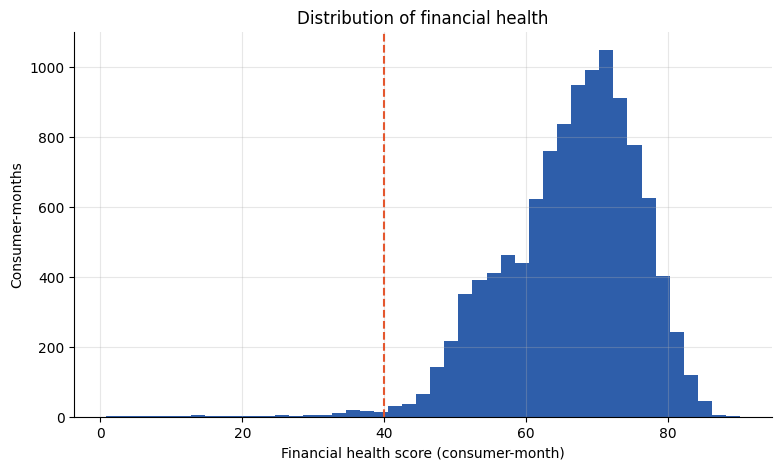

In [16]:
print("Consumer level:", cons.fhs.describe().round(2).to_dict(), "| skew", round(cons.fhs.skew(), 3))
print("Month level:   ", mon.financial_health_score.describe().round(2).to_dict())
print("\nfinancial_health_segment share of consumer-months (%):")
print((100 * mon.financial_health_segment.value_counts(normalize=True)).round(1).to_string())
print(f"\nConsumers whose 12-month average is below 40: {(cons.fhs < 40).sum()}")
print("Average FHS by month:", mon.groupby("month").financial_health_score.mean().round(1).to_dict())

fig, ax = plt.subplots()
ax.hist(mon.financial_health_score, bins=45, color="#2E5EAA")
ax.axvline(40, color="#E4572E", ls="--")
ax.set(xlabel="Financial health score (consumer-month)", ylabel="Consumer-months", title="Distribution of financial health")
plt.show()

Health sits in a tight band (consumer mean 66.3, IQR 63.4–69.3) with a mild low tail. Only 0.9% of months are stressed and no consumer is stressed on average over the year, so stress is episodic: otherwise healthy customers dip in particular months (the monthly average falls from 73.6 in February to 54.2 in December).

### D2. Factors associated with low health

In [17]:
corr = mon[["financial_health_score"] + ratios].corr()["financial_health_score"].drop("financial_health_score")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).round(3).to_string())
print("\nStressed vs healthy months:")
print(pd.DataFrame({"stressed": stressed[corr.index].mean(), "healthy": healthy[corr.index].mean()}).round(3).head(6).to_string())

spend_to_income_ratio           -0.898
credit_utilization_ratio        -0.862
spending_volatility             -0.496
essential_spend_ratio            0.481
discretionary_spend_ratio       -0.481
engagement_score                -0.299
online_spend_ratio              -0.273
average_transaction_value_vnd   -0.206
active_transaction_days         -0.145
category_diversity              -0.069
transaction_recency_days         0.017

Stressed vs healthy months:
                           stressed  healthy
spend_to_income_ratio         2.098    0.289
credit_utilization_ratio      0.582    0.078
essential_spend_ratio         0.288    0.611
discretionary_spend_ratio     0.712    0.389
online_spend_ratio            0.325    0.161
spending_volatility           3.017    0.984


              spend_to_income     fhs
sti_quintile                         
Q1 (lowest)             0.488  72.384
Q2                      0.610  68.433
Q3                      0.691  65.993
Q4                      0.774  63.760
Q5 (highest)            0.902  60.942


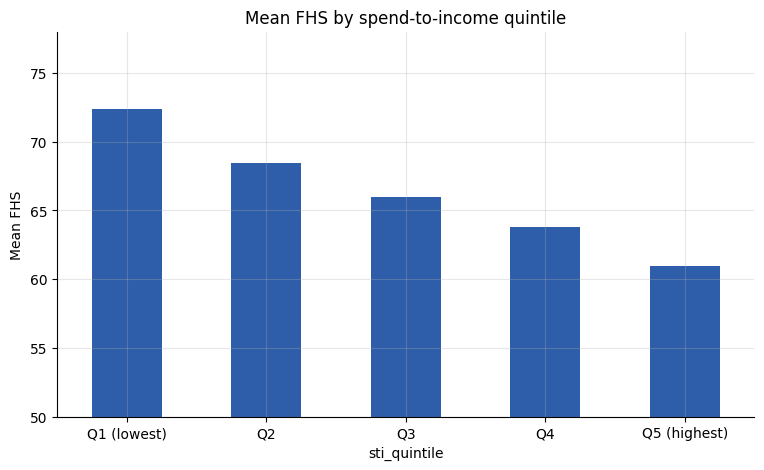

In [18]:
cons["sti_quintile"] = pd.qcut(cons.spend_to_income_ratio, 5, labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])
q = cons.groupby("sti_quintile", observed=True).agg(spend_to_income=("spend_to_income_ratio", "mean"), fhs=("fhs", "mean"))
print(q.round(3).to_string())
q["fhs"].plot.bar(color="#2E5EAA", ylim=(50, 78), rot=0, title="Mean FHS by spend-to-income quintile", ylabel="Mean FHS")
plt.show()

Low health is mainly an overspending pattern: spend-to-income (r = −0.90) and credit utilization (r = −0.86) are by far the strongest correlates. Moving from the lowest to the highest spend-to-income quintile lowers average health by 11.4 points. Stressed months are, if anything, more engaged than healthy ones. Because the score and the ratios share spend fields, we read these as associations, not causes.

### D3. Differences by province, occupation and age

In [19]:
rng = np.random.default_rng(42)
def mean_ci(s, n_boot=1000):
    return np.percentile([rng.choice(s.values, len(s)).mean() for _ in range(n_boot)], [2.5, 97.5])

national = cons.fhs.mean()
province = cons.groupby("province").fhs.agg(["size", "mean"]).query("size >= 15")
province[["ci_low", "ci_high"]] = [mean_ci(cons.loc[cons.province == p_, "fhs"]) for p_ in province.index]
province["contains_national"] = (province.ci_low <= national) & (province.ci_high >= national)
print(province.sort_values("mean").round(2).to_string())
print(f"{province.contains_national.sum()} of {len(province)} provinces have a CI containing the national mean {national:.1f}")

                       size   mean  ci_low  ci_high  contains_national
province                                                              
Thái Nguyên              18  62.98   61.53    64.60              False
Gia Lai                  15  64.17   62.16    66.21              False
Đà Nẵng                  31  64.66   63.20    66.08              False
Cà Mau                   21  64.74   62.32    66.96               True
Quảng Ngãi               17  65.27   63.68    67.21               True
Lâm Đồng                 40  65.63   63.46    67.54               True
Khánh Hòa                20  65.79   63.94    67.80               True
Đồng Nai                 49  65.93   64.98    66.96               True
Thanh Hóa                36  66.01   64.48    67.32               True
Lào Cai                  24  66.05   63.69    68.23               True
Huế                      15  66.06   63.58    68.48               True
Đồng Tháp                36  66.19   64.89    67.54               True
Vĩnh L

In [20]:
# 396 distinct job titles (max 10 people each) are too fragmented, so we group them by keywords
occupation_groups = [
    ("Student", ["sinh viên", "học sinh", "nghiên cứu sinh"]),
    ("Retired / homemaker", ["hưu", "nội trợ"]),
    ("Health", ["thầy thuốc", "bác sĩ", "y tá", "dược", "điều dưỡng", "y sĩ", "nha", "vật lý trị liệu", "hộ sinh", "sinh lý", "y tế"]),
    ("Education", ["giáo viên", "giảng viên", "giáo", "gia sư", "hiệu trưởng"]),
    ("Engineering / science / IT", ["kiến trúc", "nghiên cứu", "khoa học", "kỹ sư", "kỹ thuật", "lập trình", "phần mềm", "công nghệ", "it ", "dữ liệu", "hệ thống", "mạng"]),
    ("Business / finance", ["kinh doanh", "bán hàng", "kế toán", "tài chính", "ngân hàng", "kiểm toán", "marketing", "chủ", "giám đốc", "quản lý", "thương mại", "đầu tư", "bảo hiểm"]),
    ("Office / public services", ["cán bộ", "thanh tra", "nhân viên", "chuyên viên", "thư ký", "hành chính", "trợ lý", "tư vấn", "luật", "thiết kế", "biên", "phóng viên", "nhà"]),
    ("Manual / trades", ["họa sĩ", "nghệ", "công nhân", "thợ", "lái", "nông", "bảo vệ", "đầu bếp", "phụ", "vận", "xây", "lao động", "ngư"]),
]
def occupation_group(title):
    title = str(title).lower()
    return next((g for g, keywords in occupation_groups if any(k in title for k in keywords)), "Other")

cons["occupation_group"] = cons.occupation.map(occupation_group)
occ = cons.groupby("occupation_group").agg(n=("fhs", "size"), fhs=("fhs", "mean"), spend_to_income=("spend_to_income_ratio", "mean"))
print(occ.sort_values("fhs").round(3).to_string())

                              n     fhs  spend_to_income
occupation_group                                        
Manual / trades              23  62.942            0.793
Other                        45  63.823            0.750
Office / public services    443  64.498            0.756
Retired / homemaker           4  65.077            0.723
Education                    59  65.384            0.709
Health                       67  67.730            0.643
Business / finance          126  68.653            0.612
Engineering / science / IT  229  69.126            0.605
Student                       3  69.397            0.611


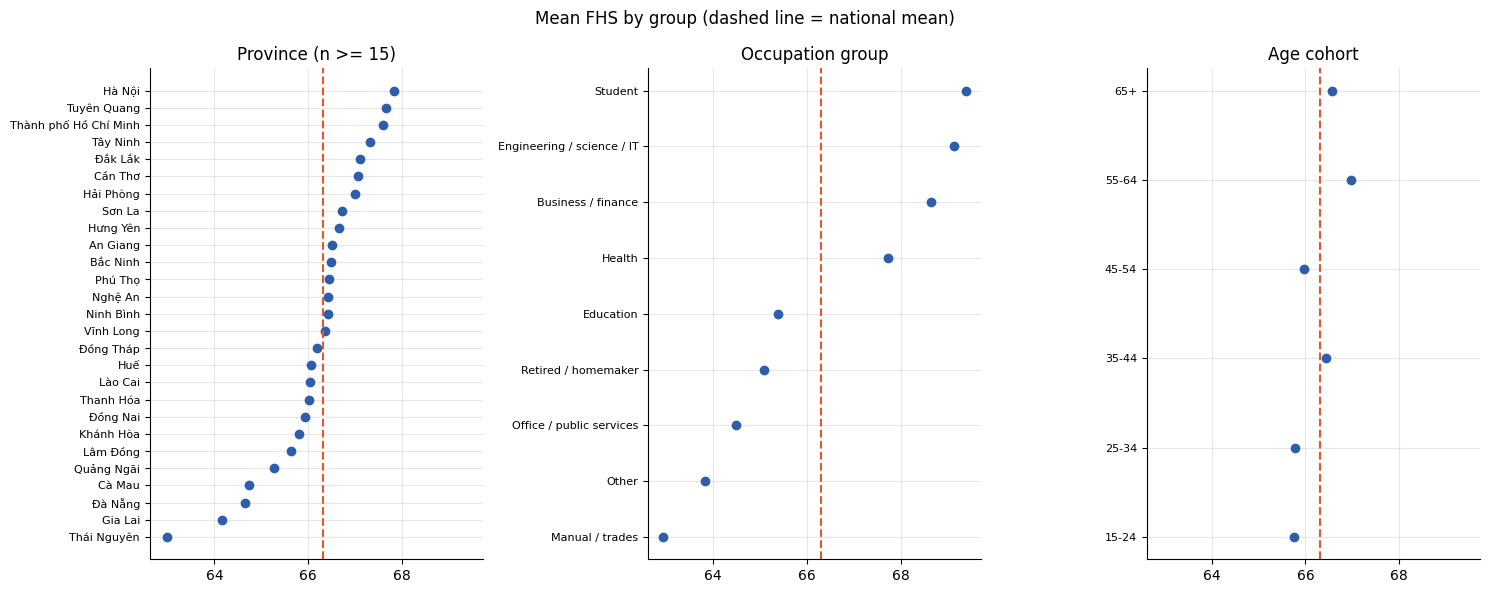

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
for ax, (title, table) in zip(axes, [("Province (n >= 15)", province.sort_values("mean")["mean"]),
                                     ("Occupation group", occ.sort_values("fhs")["fhs"]),
                                     ("Age cohort", ci["mean"])]):
    ax.plot(table.values, range(len(table)), "o", color="#2E5EAA")
    ax.set_yticks(range(len(table)), table.index, fontsize=8)
    ax.axvline(national, color="#E4572E", ls="--")
    ax.set_title(title)
fig.suptitle("Mean FHS by group (dashed line = national mean)")
plt.tight_layout(); plt.show()

Province and age barely matter: 22 of 27 provinces are statistically indistinguishable from the national mean, and all age cohorts overlap. Occupation shows a ~6-point spread (engineering/science/IT and business/finance around 69 vs office/public services 64.5 and manual trades 62.9), but it follows spend-to-income almost exactly (0.60 vs 0.76–0.79). Demographics act through the overspending ratio, so we target the ratio rather than the group.

### D4. Financially stressed but highly engaged customers
Rule, applied at consumer-month level because no consumer is stressed on average: `financial_health_score < 40` and `engagement_score >= 75th percentile`.

In [22]:
eng_p75 = mon.engagement_score.quantile(0.75)
crossover = stressed[stressed.engagement_score >= eng_p75]
print(f"Engagement 75th percentile: {eng_p75:.1f}")
print(f"Crossover: {crossover.consumer_id.nunique()} consumers, {len(crossover)} months = "
      f"{100 * len(crossover) / len(stressed):.1f}% of all {len(stressed)} stressed months")
print(pd.DataFrame({"crossover": crossover[["spend_to_income_ratio", "credit_utilization_ratio", "online_spend_ratio", "engagement_score"]].mean(),
                    "all months": mon[["spend_to_income_ratio", "credit_utilization_ratio", "online_spend_ratio", "engagement_score"]].mean()}).round(3).to_string())

Engagement 75th percentile: 81.4
Crossover: 43 consumers, 49 months = 51.6% of all 95 stressed months
                          crossover  all months
spend_to_income_ratio         1.890       0.700
credit_utilization_ratio      0.548       0.192
online_spend_ratio            0.486       0.210
engagement_score             88.639      77.819


In [23]:
# sensitivity of the rule to both cutoffs
rows = []
for fhs_cut in (35, 40, 45):
    st = mon[mon.financial_health_score < fhs_cut]
    for pct in (0.70, 0.75, 0.80):
        cx = st[st.engagement_score >= mon.engagement_score.quantile(pct)]
        rows.append((f"FHS<{fhs_cut}", f"p{int(pct * 100)}", cx.consumer_id.nunique(), len(cx), round(100 * len(cx) / len(st), 1)))
print(pd.DataFrame(rows, columns=["health", "engagement", "consumers", "months", "% of stressed months"]).to_string(index=False))

health engagement  consumers  months  % of stressed months
FHS<35        p70         24      27                  49.1
FHS<35        p75         23      26                  47.3
FHS<35        p80         22      24                  43.6
FHS<40        p70         44      50                  52.6
FHS<40        p75         43      49                  51.6
FHS<40        p80         41      46                  48.4
FHS<45        p70         91     105                  59.7
FHS<45        p75         89     103                  58.5
FHS<45        p80         86      99                  56.2


Share of spend VALUE by hour (%)
 state      healthy  stressed
hour_band                   
00-05         25.1      16.7
06-11         24.7      13.6
12-17         24.8      29.9
18-21         17.1      16.3
22-23          8.3      23.5

Share of transaction COUNT by hour (%)
 state      healthy  stressed
hour_band                   
00-05         21.4      20.8
06-11         21.5      19.7
12-17         28.4      28.9
18-21         19.1      19.0
22-23          9.7      11.6

Per stressed month, median share of spend at 22-23h: 23.0% (51 of 95 months above 20%)


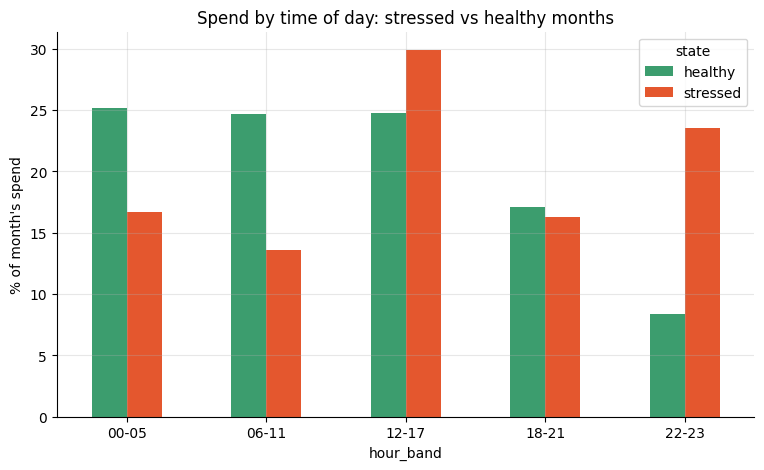

In [24]:
# when do stressed months spend? (transaction timestamps)
t = txn.merge(mon[["consumer_id", "month", "financial_health_score"]], left_on=["consumer_id", "transaction_month"], right_on=["consumer_id", "month"])
t["state"] = np.select([t.financial_health_score < 40, t.financial_health_score >= 80], ["stressed", "healthy"], "other")
t = t[t.state != "other"]
t["hour_band"] = pd.cut(t.transaction_hour, [-1, 5, 11, 17, 21, 23], labels=["00-05", "06-11", "12-17", "18-21", "22-23"])
value_share = pd.crosstab(t.hour_band, t.state, values=t.spend_amount_vnd, aggfunc="sum", normalize="columns") * 100
count_share = pd.crosstab(t.hour_band, t.state, normalize="columns") * 100
print("Share of spend VALUE by hour (%)\n", value_share.round(1).to_string())
print("\nShare of transaction COUNT by hour (%)\n", count_share.round(1).to_string())
late = t[t.state == "stressed"].groupby(["consumer_id", "transaction_month"]).apply(
    lambda d: 100 * d.loc[d.transaction_hour >= 22, "spend_amount_vnd"].sum() / d.spend_amount_vnd.sum(), include_groups=False)
print(f"\nPer stressed month, median share of spend at 22-23h: {late.median():.1f}% ({(late > 20).sum()} of {len(late)} months above 20%)")

value_share.plot.bar(color={"healthy": "#3C9D6E", "stressed": "#E4572E"}, rot=0, ylabel="% of month's spend",
                     title="Spend by time of day: stressed vs healthy months")
plt.show()

The rule captures 43 consumers and 49 months, which is 52% of all stress episodes. Changing the engagement cutoff to the 70th or 80th percentile keeps it at 41–44 consumers, so the result is stable. These customers spend almost twice their income and use half their credit line, yet they are very active and online, which makes them easy to reach in-app.

The transaction file adds timing: stressed months put 23.5% of their spend value into 22:00–23:59 (8.3% in healthy months), while the transaction count there is similar (11.6% vs 9.7%), so late-night purchases are larger, not more frequent. The pattern holds month by month (median 23%), so the late evening is when a spend alert is most useful.

## Task 3: Customer Engagement Analysis
### D1. Engagement score distribution and segment shares

count    10992.00
mean        77.82
std          6.33
min          9.70
25%         74.80
50%         78.10
75%         81.40
max         99.60

Official bands (from the data): {'Tương tác cao': {'min': 60.1, 'max': 79.9}, 'Tương tác rất cao': {'min': 80.0, 'max': 99.6}, 'Tương tác thấp': {'min': 9.7, 'max': 39.7}, 'Tương tác trung bình': {'min': 40.5, 'max': 59.9}}
Share of consumer-months by segment (%): {'Tương tác cao': 64.2, 'Tương tác rất cao': 34.8, 'Tương tác trung bình': 0.9, 'Tương tác thấp': 0.1}

Consumers by segment of their average score:
                  consumers     %
engagement_score                 
Low                      10   1.0
Medium                   80   8.0
High                    668  66.9
Very high               241  24.1

Months observed per consumer: {1: 86, 2: 5, 12: 908}
Lowest average engagement among full-year consumers: 69.8; highest among consumers seen in 1-2 months: 61.6


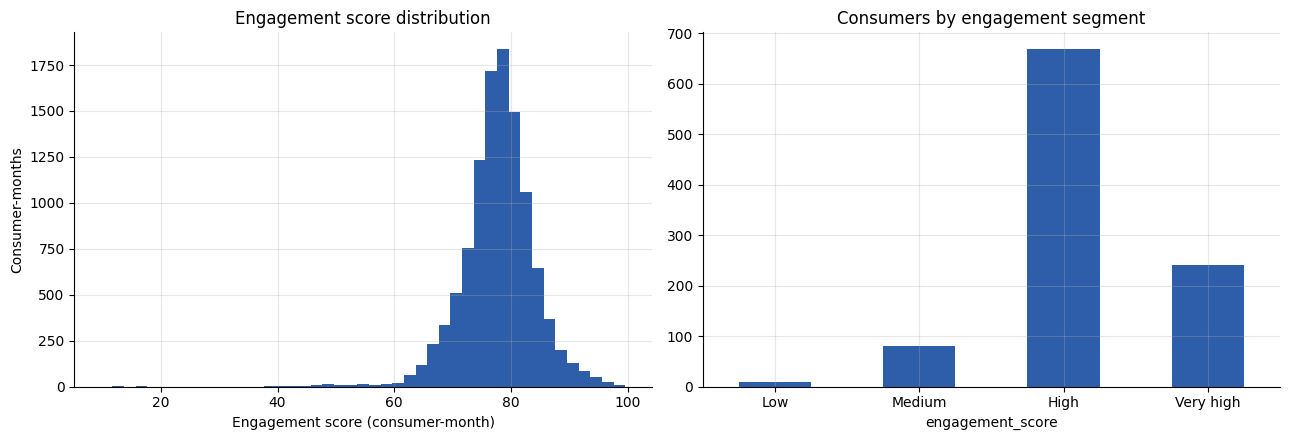

In [25]:
print(mon.engagement_score.describe().round(2).to_string())
print("\nOfficial bands (from the data):", mon.groupby("engagement_segment").engagement_score.agg(["min", "max"]).to_dict("index"))
print("Share of consumer-months by segment (%):", (100 * mon.engagement_segment.value_counts(normalize=True)).round(1).to_dict())
avg_eng = mon.groupby("consumer_id").engagement_score.mean()
seg_share = pd.cut(avg_eng, [0, 40, 60, 80, 101], right=False, labels=["Low", "Medium", "High", "Very high"]).value_counts().sort_index()
print("\nConsumers by segment of their average score:")
print(pd.DataFrame({"consumers": seg_share, "%": (100 * seg_share / 999).round(1)}).to_string())
months_seen = mon.groupby("consumer_id").size()
print(f"\nMonths observed per consumer: {months_seen.value_counts().sort_index().to_dict()}")
print(f"Lowest average engagement among full-year consumers: {avg_eng[months_seen == 12].min():.1f}; "
      f"highest among consumers seen in 1-2 months: {avg_eng[months_seen < 12].max():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(mon.engagement_score, bins=45, color="#2E5EAA")
axes[0].set(xlabel="Engagement score (consumer-month)", ylabel="Consumer-months", title="Engagement score distribution")
seg_share.plot.bar(ax=axes[1], rot=0, color="#2E5EAA", title="Consumers by engagement segment")
plt.tight_layout(); plt.show()

### D2. Channel adoption and online spend share

                     % of transactions  % of spend
transaction_channel                               
E-commerce                         8.7         9.6
Mobile App                         7.7         7.6
POS                               58.8        58.5
QR Payment                        19.8        19.6
Recurring Payment                  4.9         4.6

Average online spend share per consumer: 24.7% (range 0.00-0.95)


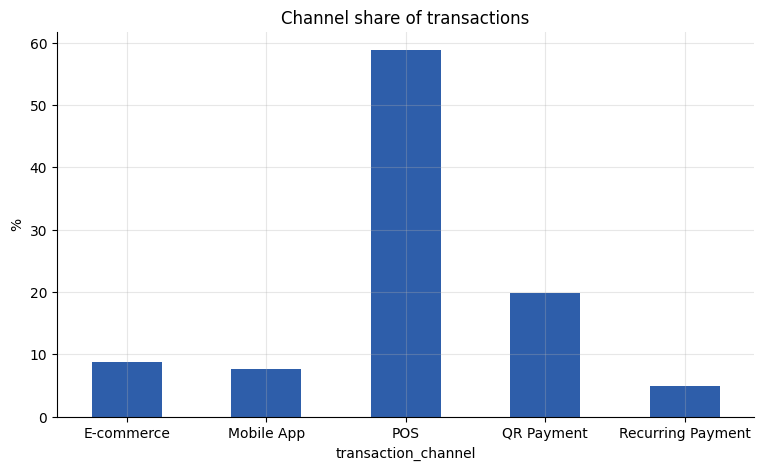

In [26]:
channel_share = pd.DataFrame({"% of transactions": 100 * txn.transaction_channel.value_counts(normalize=True),
                              "% of spend": 100 * txn.groupby("transaction_channel").spend_amount_vnd.sum() / txn.spend_amount_vnd.sum()})
print(channel_share.round(1).to_string())
cons_eng = mon.groupby("consumer_id").mean(numeric_only=True)
print(f"\nAverage online spend share per consumer: {100 * cons_eng.online_spend_ratio.mean():.1f}% "
      f"(range {cons_eng.online_spend_ratio.min():.2f}-{cons_eng.online_spend_ratio.max():.2f})")
channel_share["% of transactions"].plot.bar(rot=0, color="#2E5EAA", title="Channel share of transactions", ylabel="%")
plt.show()

Engagement is saturated: 91% of consumers are in the high or very-high segment, so the score on its own does not separate customers. The whole low tail is the 91 customers who appear in only one or two months of 2025 (1–2 active days); every full-year customer averages at least 69.8. POS carries 59% of transactions; QR is the second rail at 20%. Non-POS channels carry 41% of transactions and 41.5% of value, and the average customer's online share of spend is 24.7%, with a wide range (0–95%).

### D3. Category diversity and engagement

Category diversity (consumer average): min 2, max 14, mean 12.94
Consumers at 13-14 categories: 880 of 999
Correlation with engagement: all 0.938, diversity >= 8 only 0.811, Spearman 0.845


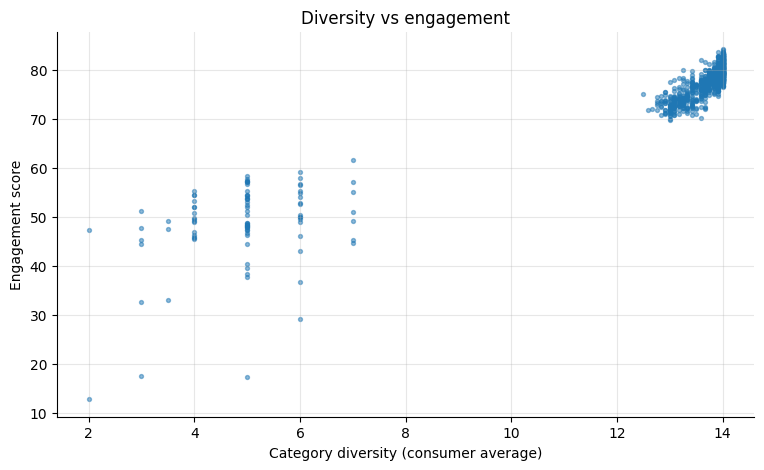

In [27]:
print(f"Category diversity (consumer average): min {cons_eng.category_diversity.min():.0f}, max {cons_eng.category_diversity.max():.0f}, "
      f"mean {cons_eng.category_diversity.mean():.2f}")
core = cons_eng[cons_eng.category_diversity >= 8]
print(f"Consumers at 13-14 categories: {(cons_eng.category_diversity >= 13).sum()} of 999")
print(f"Correlation with engagement: all {cons_eng.category_diversity.corr(cons_eng.engagement_score):.3f}, "
      f"diversity >= 8 only {core.category_diversity.corr(core.engagement_score):.3f}, "
      f"Spearman {cons_eng.category_diversity.corr(cons_eng.engagement_score, method='spearman'):.3f}")
plt.scatter(cons_eng.category_diversity, cons_eng.engagement_score, s=8, alpha=0.5)
plt.xlabel("Category diversity (consumer average)"); plt.ylabel("Engagement score"); plt.title("Diversity vs engagement")
plt.show()

### D4. Recency and frequency

transaction_recency_days: min 0, median 0, max 30, corr with engagement -0.42
active_transaction_days: min 1, median 30, max 31, corr with engagement +0.59
transaction_count: min 2, median 150, max 713, corr with engagement +0.40
active_transaction_days    1-5  6-15  16-25  26-29  30-31
transaction_recency_days                                 
0 d                       54.9   NaN   73.0   76.9   79.8
1-3 d                     54.8  66.1   71.3   75.4   76.9
4-10 d                    52.8   NaN   55.7    NaN    NaN
11-30 d                   43.6   NaN    NaN    NaN    NaN


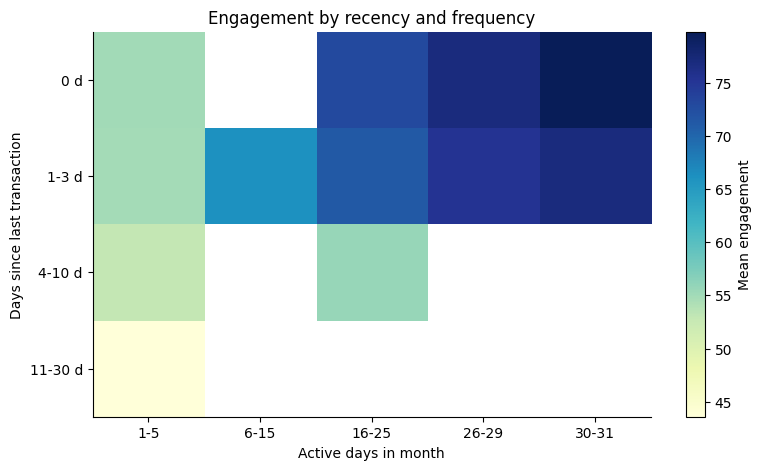

In [28]:
for c in ["transaction_recency_days", "active_transaction_days", "transaction_count"]:
    print(f"{c}: min {mon[c].min():.0f}, median {mon[c].median():.0f}, max {mon[c].max():.0f}, "
          f"corr with engagement {mon[c].corr(mon.engagement_score):+.2f}")
recency_bin = pd.cut(mon.transaction_recency_days, [-0.1, 0, 3, 10, 31], labels=["0 d", "1-3 d", "4-10 d", "11-30 d"])
freq_bin = pd.cut(mon.active_transaction_days, [0, 5, 15, 25, 29, 31], labels=["1-5", "6-15", "16-25", "26-29", "30-31"])
heat = mon.pivot_table(index=recency_bin, columns=freq_bin, values="engagement_score", aggfunc="mean", observed=False)
print(heat.round(1).to_string())
plt.imshow(heat.values, cmap="YlGnBu", aspect="auto")
plt.xticks(range(heat.shape[1]), heat.columns); plt.yticks(range(heat.shape[0]), heat.index)
plt.xlabel("Active days in month"); plt.ylabel("Days since last transaction"); plt.colorbar(label="Mean engagement")
plt.title("Engagement by recency and frequency"); plt.grid(False)
plt.show()

Diversity (2–14 categories, most customers at 13–14) is the clearest engagement signal: r = +0.94, and still +0.81 when the small dormant tail is removed. For recency and frequency, the number of active days (r = +0.59) matters more than recency (−0.42) or raw transaction count (+0.40). Customers active on only 1–5 days stay below 55 regardless of how recently they transacted.

### D5. Financially healthy but disengaged customers
The task gives no cutoff, so we choose it from the data: FHS >= 70 (top ~21% of consumers) and engagement < 70 (below the 10th percentile, 71.1).

In [29]:
fhs_c, eng_c = cons_eng.financial_health_score, cons_eng.engagement_score
print(f"engagement p10 {eng_c.quantile(0.10):.1f}, p25 {eng_c.quantile(0.25):.1f} | share with FHS >= 70: {100 * (fhs_c >= 70).mean():.1f}%")
dormant = cons_eng[(fhs_c >= 70) & (eng_c < 70)]
print(f"Group size: {len(dormant)} consumers ({100 * len(dormant) / 999:.1f}%)")
sensitivity = pd.DataFrame({f"eng<{e}": [((fhs_c >= f) & (eng_c < e)).sum() for f in (65, 70, 75)] for e in (60, 65, 70, 72, 74, 75)},
                           index=[f"FHS>={f}" for f in (65, 70, 75)])
print(sensitivity.to_string())
profile_cols = ["financial_health_score", "engagement_score", "transaction_count", "active_transaction_days",
                "transaction_recency_days", "category_diversity", "online_spend_ratio"]
print(pd.DataFrame({"group": dormant[profile_cols].mean(), "rest": cons_eng.drop(dormant.index)[profile_cols].mean()}).round(2).to_string())

engagement p10 71.1, p25 74.8 | share with FHS >= 70: 21.1%
Group size: 25 consumers (2.5%)
         eng<60  eng<65  eng<70  eng<72  eng<74  eng<75
FHS>=65      47      47      48      72     130     156
FHS>=70      25      25      25      36      52      63
FHS>=75       9       9       9      10      12      14
                          group    rest
financial_health_score    74.03   66.10
engagement_score          46.83   76.13
transaction_count          9.92  159.06
active_transaction_days    2.00   27.04
transaction_recency_days  14.28    0.91
category_diversity         4.68   13.15
online_spend_ratio         0.61    0.24


The group has 25 consumers (2.5%). The count stays at 25 for any engagement cutoff between 60 and 70, which is a natural gap in the data; a looser cutoff (72–75) starts pulling in the main body (36–63 consumers), and a stricter health cutoff (75) leaves only 9. These customers are healthy (FHS 74) but transact on about 2 days a month, in 4–5 categories, mostly online. They need reactivation of everyday use, not budgeting support.

## Task 4: Customer Segmentation
### Preprocessing and features
We aggregate each consumer's months to one row (yearly mean of each ratio) and cluster on eight scaled behavioural features covering health, engagement and spending. Raw VND is excluded; `essential_spend_ratio` is dropped because it equals 1 − discretionary; diversity, active days and recency are dropped because they are near-constant (75th percentile = maximum). Demographics are kept only for profiling.

In [30]:
features = ["financial_health_score", "spend_to_income_ratio", "credit_utilization_ratio", "spending_volatility",
            "engagement_score", "transaction_count", "discretionary_spend_ratio", "online_spend_ratio"]
seg = mon.groupby("consumer_id")[features].mean()
demo = mon.groupby("consumer_id").agg(age=("age", "first"), gender=("gender", "first"),
                                      occupation=("occupation", "first"), province=("province_city", "first"))
scaler = StandardScaler().fit(seg)
X = scaler.transform(seg)
print(seg.shape, "| missing values:", seg.isna().sum().sum())

(999, 8) | missing values: 0


### Model selection

    inertia  silhouette
2  5212.173       0.557
3  3719.981       0.295
4  3227.753       0.251
5  2879.509       0.232
6  2669.648       0.220
7  2478.199       0.206
8  2301.025       0.217


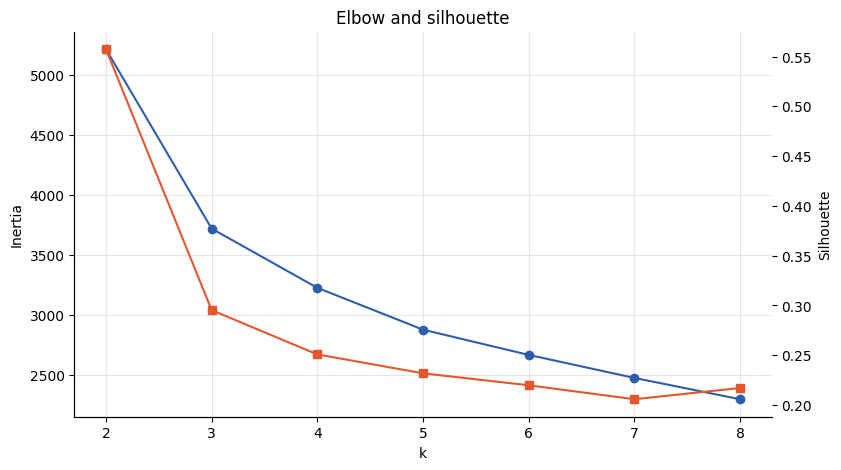

In [31]:
k_scores = {}
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    k_scores[k] = (model.inertia_, silhouette_score(X, model.labels_))
k_scores = pd.DataFrame(k_scores, index=["inertia", "silhouette"]).T
print(k_scores.round(3).to_string())

fig, ax = plt.subplots()
ax.plot(k_scores.index, k_scores.inertia, marker="o", color="#2E5EAA"); ax.set(xlabel="k", ylabel="Inertia")
ax2 = ax.twinx(); ax2.plot(k_scores.index, k_scores.silhouette, marker="s", color="#E4572E"); ax2.set_ylabel("Silhouette"); ax2.grid(False)
plt.title("Elbow and silhouette"); plt.show()

k = 2 has the highest silhouette but only splits healthy from stretched customers. The elbow is at k = 4, which is also the best silhouette in the 4–6 range, so we use four clusters.

In [32]:
km = KMeans(n_clusters=4, n_init=25, random_state=42).fit(X)
seg["cluster"] = km.labels_
profile = seg.groupby("cluster")[features].mean()
names = {profile.financial_health_score.idxmax(): "Healthy & Engaged",
         profile.spend_to_income_ratio.idxmax(): "Stretched & Engaged",
         profile.transaction_count.idxmax(): "High-Activity Users",
         profile.engagement_score.idxmin(): "Occasional Online-First"}  # the brief's "Emerging Digital"
assert len(names) == 4
seg["segment"] = seg.cluster.map(names)
print(f"Silhouette: {silhouette_score(X, km.labels_):.3f} | consumers assigned: {seg.segment.notna().sum()} / 999")
summary = seg.groupby("segment")[features].mean()
summary.insert(0, "n", seg.segment.value_counts())
summary.insert(1, "%", (100 * summary["n"] / 999).round(1))
print(summary.round(3).T.to_string())

Silhouette: 0.251 | consumers assigned: 999 / 999
segment                    Healthy & Engaged  High-Activity Users  Occasional Online-First  Stretched & Engaged
n                                    351.000              258.000                   88.000              302.000
%                                     35.100               25.800                    8.800               30.200
financial_health_score                70.490               65.101                   65.694               62.640
spend_to_income_ratio                  0.571                0.718                    0.614                0.835
credit_utilization_ratio               0.148                0.188                    0.173                0.248
spending_volatility                    1.443                1.910                    0.679                1.423
engagement_score                      77.421               80.156                   49.550               76.524
transaction_count                    152.722          

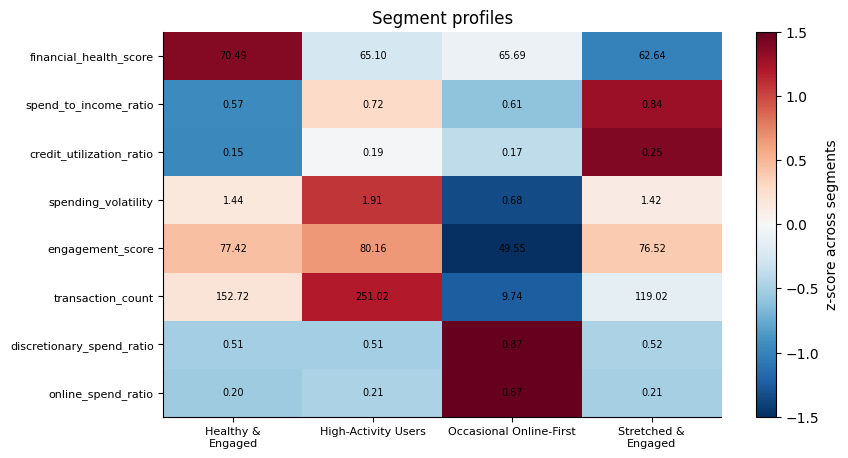

In [33]:
z = (summary[features] - summary[features].mean()) / summary[features].std()
plt.figure(figsize=(9, 5))
plt.imshow(z.T.values, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)
plt.xticks(range(4), [s.replace(" & ", " &\n").replace(" but ", "\nbut ") for s in z.index], fontsize=8)
plt.yticks(range(len(features)), features, fontsize=8)
for i in range(len(features)):
    for j in range(4):
        plt.text(j, i, f"{summary[features].iloc[j, i]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(label="z-score across segments"); plt.title("Segment profiles"); plt.grid(False)
plt.show()

### Validation

In [34]:
base = seg["cluster"].values
seed_ari = [adjusted_rand_score(base, KMeans(4, n_init=10, random_state=s).fit_predict(X)) for s in range(20)]
rng = np.random.default_rng(42)
boot_ari = []
for _ in range(50):
    idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
    boot_ari.append(adjusted_rand_score(base, KMeans(4, n_init=10, random_state=42).fit(X[idx]).predict(X)))
gmm = GaussianMixture(4, covariance_type="full", n_init=5, random_state=42).fit(X)
print(f"ARI across 20 seeds: mean {np.mean(seed_ari):.3f}, min {min(seed_ari):.3f}")
print(f"ARI on 50 bootstrap samples (80%): mean {np.mean(boot_ari):.3f}")
print(f"ARI k-means vs GMM: {adjusted_rand_score(base, gmm.predict(X)):.3f}; "
      f"consumers with max GMM probability < 0.6: {(gmm.predict_proba(X).max(axis=1) < 0.6).mean():.1%}")

# rule-based 2x2 on medians as a cross-check
rule = np.where(seg.financial_health_score >= seg.financial_health_score.median(), "Healthy", "Stretched")
rule = rule + np.where(seg.engagement_score >= seg.engagement_score.median(), " + Engaged", " + Disengaged")
print(pd.crosstab(seg.segment, rule).to_string())

ARI across 20 seeds: mean 0.988, min 0.931
ARI on 50 bootstrap samples (80%): mean 0.911
ARI k-means vs GMM: 0.259; consumers with max GMM probability < 0.6: 3.4%
col_0                    Healthy + Disengaged  Healthy + Engaged  Stretched + Disengaged  Stretched + Engaged
segment                                                                                                      
Healthy & Engaged                         182                162                       5                    2
High-Activity Users                        11                 78                      21                  148
Occasional Online-First                    39                  0                      49                    0
Stretched & Engaged                        26                  3                     163                  110


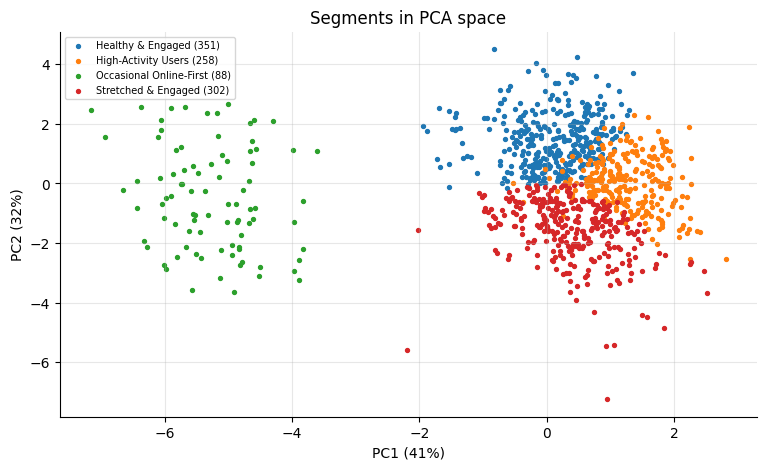

In [35]:
pcs = PCA(2, random_state=42).fit(X)
P = pcs.transform(X)
for s_ in summary.index:
    m_ = (seg.segment == s_).values
    plt.scatter(P[m_, 0], P[m_, 1], s=8, label=f"{s_} ({m_.sum()})")
plt.xlabel(f"PC1 ({pcs.explained_variance_ratio_[0]:.0%})"); plt.ylabel(f"PC2 ({pcs.explained_variance_ratio_[1]:.0%})")
plt.legend(fontsize=7); plt.title("Segments in PCA space"); plt.show()

The solution is stable (ARI 0.99 across seeds and 0.91 on bootstrap samples). A Gaussian mixture reproduces the Occasional Online-First group exactly but cuts the three large groups differently (ARI 0.26): as the PCA plot shows, they form one continuum, which also explains the moderate silhouette of 0.25.

### Post-segmentation analysis: monthly migration and demographics

December consumer-months by nearest segment profile (%): {'Stretched & Engaged': 77.3, 'High-Activity Users': 19.9, 'Healthy & Engaged': 1.7, 'Occasional Online-First': 1.0}
month                  11    12  change
segment                                
Healthy & Engaged    71.3  58.5   -12.8
High-Activity Users  66.4  53.0   -13.4
Stretched & Engaged  64.2  50.0   -14.2


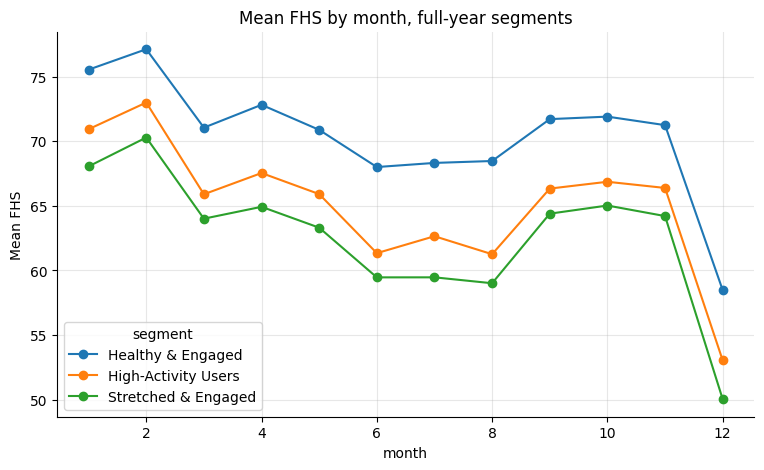

In [36]:
# which segment each consumer-month looks like, and how health moves through the year per segment
monthly = mon.copy()
monthly["month_profile"] = pd.Series(km.predict(scaler.transform(monthly[features])), index=monthly.index).map(names)
print("December consumer-months by nearest segment profile (%):",
      (100 * monthly[monthly.month == 12].month_profile.value_counts(normalize=True)).round(1).to_dict())
full_year = months_seen[months_seen == 12].index
monthly["segment"] = monthly.consumer_id.map(seg.segment)
trend = monthly[monthly.consumer_id.isin(full_year)].pivot_table(index="month", columns="segment", values="financial_health_score")
nov_dec = trend.loc[[11, 12]].T
nov_dec["change"] = nov_dec[12] - nov_dec[11]
print(nov_dec.round(1).to_string())
trend.plot(marker="o", title="Mean FHS by month, full-year segments", ylabel="Mean FHS"); plt.show()

In [37]:
profiled = seg.join(demo)
print(profiled.groupby("segment").age.mean().round(1).to_string())
print((100 * pd.crosstab(profiled.segment, profiled.gender, normalize="index")).round(1).to_string())
age_group = pd.cut(profiled.age, [14, 17, 24, 34, 44, 54, 64, 120])
for col, values in [("gender", profiled.gender), ("age group", age_group)]:
    print(f"chi-square segment x {col}: p = {chi2_contingency(pd.crosstab(profiled.segment, values))[1]:.4f}")

segment
Healthy & Engaged          52.7
High-Activity Users        43.2
Occasional Online-First    57.9
Stretched & Engaged        50.6
gender                    Nam    Nữ
segment                            
Healthy & Engaged        49.9  50.1
High-Activity Users      39.5  60.5
Occasional Online-First  52.3  47.7
Stretched & Engaged      56.6  43.4
chi-square segment x gender: p = 0.0008
chi-square segment x age group: p = 0.0000


In [38]:
# suggested personas from the brief that did not form their own cluster
essential_focused = seg[seg.discretionary_spend_ratio < 0.40]
healthy_disengaged = seg[(seg.financial_health_score >= 70) & (seg.engagement_score < 70)]
print("Essential-spend-focused (discretionary < 40%):", len(essential_focused))
print("Healthy but disengaged:", len(healthy_disengaged), healthy_disengaged.segment.value_counts().to_dict())

Essential-spend-focused (discretionary < 40%): 4
Healthy but disengaged: 25 {'Occasional Online-First': 24, 'Healthy & Engaged': 1}


In [39]:
# preprocessed dataset used for modelling (submitted with the deck)
export = seg.join(pd.DataFrame(X, index=seg.index, columns=[f"z_{f}" for f in features])).join(demo)
export.to_csv("task4_features.csv")
print(export.shape)

(999, 22)


Segment summary:
- Healthy & Engaged, 351 (35.1%): highest health, lowest spend-to-income and utilization. Retain and grow value.
- Stretched & Engaged, 302 (30.2%): highest spend-to-income (0.84) and utilization, still fully active. The wellbeing priority.
- High-Activity Users, 258 (25.8%): most transactions and most volatile spending, but not more online than the other full-year groups. Planning support.
- Occasional Online-First, 88 (8.8%, the brief's "Emerging Digital"): customers seen in only one or two months, mostly online and discretionary. Build a habit.

Most December months look like the stretched profile, but that is the calendar, not customers switching: average health drops by about 13 points from November to December in all three full-year segments alike, which supports a planning reminder for everyone in November. Segments were built without demographics but still differ by age and gender (p < 0.01), so interventions should be triggered by behaviour, never targeted by demographics.

Limitations: moderate silhouette (segments sit on a continuum); yearly averages hide trajectories; synthetic data with two folded years; the Occasional group rests on one or two months of data per customer. Future work: refit on multi-year data, add trend features (e.g. health slope), use soft membership for boundary customers, and build a chronological early-warning model for `next_month_low_health_flag`.

## Task 5: Business Recommendations
### Target group sizes

In [40]:
sizes = seg.segment.value_counts()
distress_tail = seg[(seg.financial_health_score < 70) & (seg.engagement_score < 70)]  # yearly means, both below 70
targets = pd.DataFrame([
    ("Budgeting tool", "Stretched & Engaged", sizes["Stretched & Engaged"], "spend_to_income_ratio", "financial_health_score", "wellbeing"),
    ("Spend alerts", "Stressed & engaged crossover", crossover.consumer_id.nunique(), "credit_utilization_ratio", "financial_health_score", "wellbeing"),
    ("Planning reminders", "High-Activity Users", sizes["High-Activity Users"], "spending_volatility", "financial_health_score", "wellbeing"),
    ("Financial education", "Low health & low engagement", len(distress_tail), "discretionary_spend_ratio", "financial_health_score", "wellbeing"),
    ("Digital nudges", "Occasional Online-First", sizes["Occasional Online-First"], "category_diversity", "engagement_score", "growth"),
    ("Product suggestions", "Healthy & Engaged (adults 18+)", int(((seg.segment == "Healthy & Engaged") & (demo.age >= 18)).sum()), "credit_utilization_ratio", "engagement_score", "growth"),
], columns=["tool", "target group", "reach", "trigger column", "outcome", "track"])
targets["% of 999"] = (100 * targets.reach / 999).round(1)
# driver strength = |r| between the trigger column and the outcome the tool should move (month level)
targets["driver |r|"] = [abs(mon[c].corr(mon[o])) for c, o in zip(targets["trigger column"], targets["outcome"])]
targets["score"] = (targets.reach * targets["driver |r|"]).round(0)
targets = targets.sort_values(["track", "score"], ascending=[False, False])  # wellbeing before growth
print(targets.round(3).to_string(index=False))
print("\nOverlaps: crossover by segment", seg.loc[crossover.consumer_id.unique(), "segment"].value_counts().to_dict(),
      "| low health & low engagement by segment", distress_tail.segment.value_counts().to_dict())

               tool                   target group  reach            trigger column                outcome     track  % of 999  driver |r|  score
     Budgeting tool            Stretched & Engaged    302     spend_to_income_ratio financial_health_score wellbeing      30.2       0.898  271.0
 Planning reminders            High-Activity Users    258       spending_volatility financial_health_score wellbeing      25.8       0.496  128.0
       Spend alerts   Stressed & engaged crossover     43  credit_utilization_ratio financial_health_score wellbeing       4.3       0.862   37.0
Financial education    Low health & low engagement     67 discretionary_spend_ratio financial_health_score wellbeing       6.7       0.481   32.0
Product suggestions Healthy & Engaged (adults 18+)    350  credit_utilization_ratio       engagement_score    growth      35.0       0.212   74.0
     Digital nudges        Occasional Online-First     88        category_diversity       engagement_score    growth       8

### Expected impact (illustrative scenario)
A simple month-level fit of health on spend-to-income lets us ask what a small reduction in overspending would do for the stretched segment. This is a scenario to test with a control group, not a forecast, since the score is partly built from spend.

In [41]:
slope, intercept = np.polyfit(mon.spend_to_income_ratio, mon.financial_health_score, 1)
print(f"FHS = {intercept:.1f} + ({slope:.2f}) x spend_to_income")
stretched_ids = seg.index[seg.segment == "Stretched & Engaged"]
in_stretched = mon.consumer_id.isin(stretched_ids)
assert in_stretched.any()
slope_s = np.polyfit(mon.loc[in_stretched, "spend_to_income_ratio"], mon.loc[in_stretched, "financial_health_score"], 1)[0]
print(f"slope inside the stretched segment: {slope_s:.1f}")
for cut in (0, 0.05, 0.10, 0.15):
    months = [((mon.financial_health_score - b * mon.spend_to_income_ratio * cut * in_stretched) < 40).sum() for b in (slope, slope_s)]
    print(f"spend-to-income -{int(cut * 100)}% for the stretched segment -> stressed months: {months[0]} (all-customer slope), {months[1]} (stretched-only slope)")
print("stressed months outside the stretched segment:", (~in_stretched & (mon.financial_health_score < 40)).sum())

FHS = 84.1 + (-25.33) x spend_to_income
slope inside the stretched segment: -22.2
spend-to-income -0% for the stretched segment -> stressed months: 95 (all-customer slope), 95 (stretched-only slope)
spend-to-income -5% for the stretched segment -> stressed months: 80 (all-customer slope), 81 (stretched-only slope)
spend-to-income -10% for the stretched segment -> stressed months: 65 (all-customer slope), 68 (stretched-only slope)
spend-to-income -15% for the stretched segment -> stressed months: 49 (all-customer slope), 53 (stretched-only slope)
stressed months outside the stretched segment: 9


Recommendations, ranked by score = reach × driver strength, wellbeing tools first:
1. Budgeting tool for the 302 stretched customers: a spend-vs-income view with discretionary categories highlighted.
2. Planning reminders for the 258 high-activity customers, with a year-end plan sent in November before the December drop.
3. Spend alerts for the 43 crossover customers (52% of stress months): opt-in, in the evening before 22:00. Small but precise, so launched first.
4. Financial education for the 67 low-health, low-engagement customers: short needs-vs-wants content.
5. Product suggestions for the 350 adults (18+) in Healthy & Engaged (1 minor excluded): opt-in savings or loyalty products, never a credit-line increase.
6. Digital nudges for the 88 occasional online customers, inside the channels they already use (staggered with education for the 64 who get both).

In the scenario above, a 10% cut in spend-to-income for the stretched segment would reduce stressed months from 95 to about 65 (68 with the slope estimated inside the segment), a 28–32% cut. Each tool should be tested against a random holdout group with one KPI.

Credit rule: `financial_health_score` is used only to offer help. It is never used to deny credit, reduce a credit limit, raise a rate or block an account.

## Appendix: figures used in the slide deck
Every chart in the deck is produced here from the results above, in one blue theme, and saved to `outputs/figures/deck_*.png`.

In [42]:
import matplotlib as mpl
NAVY, BLUE, MID, LIGHT, PALE, GRAY, INK = "#0B2545", "#1F5FA8", "#4A90D9", "#A9C6EA", "#DCE9F7", "#BFC8D2", "#1A2433"
mpl.rcParams.update({"font.family": "Arial", "font.size": 11, "axes.edgecolor": "#8A97A6", "axes.labelcolor": INK,
                     "xtick.color": INK, "ytick.color": INK, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#E3E8EE", "grid.linewidth": 0.8, "legend.frameon": False})
FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)
def deck_save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
BIG, HALF = (8.4, 4.6), (6.2, 3.6)
EN_CAT = {"Du lịch": "Travel", "Mua sắm trực tuyến": "Online shopping", "Mua sắm tại cửa hàng": "In-store shopping",
          "Dịch vụ trực tuyến khác": "Other online services", "Siêu thị và tạp hóa tại cửa hàng": "Groceries (in-store)",
          "Xăng dầu và di chuyển": "Fuel & transport", "Nhà cửa và tiện ích": "Home & utilities", "Trẻ em và thú cưng": "Kids & pets",
          "Sức khỏe và thể thao": "Health & sports", "Ăn uống": "Food & dining", "Chăm sóc cá nhân": "Personal care",
          "Giải trí": "Entertainment", "Tạp hóa trực tuyến": "Online groceries", "Mua sắm khác tại cửa hàng": "Other in-store"}
EN_PROV = {"Hà Nội": "Ha Noi", "Đồng Nai": "Dong Nai", "Lâm Đồng": "Lam Dong", "Hưng Yên": "Hung Yen", "Hải Phòng": "Hai Phong", "Nghệ An": "Nghe An"}
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

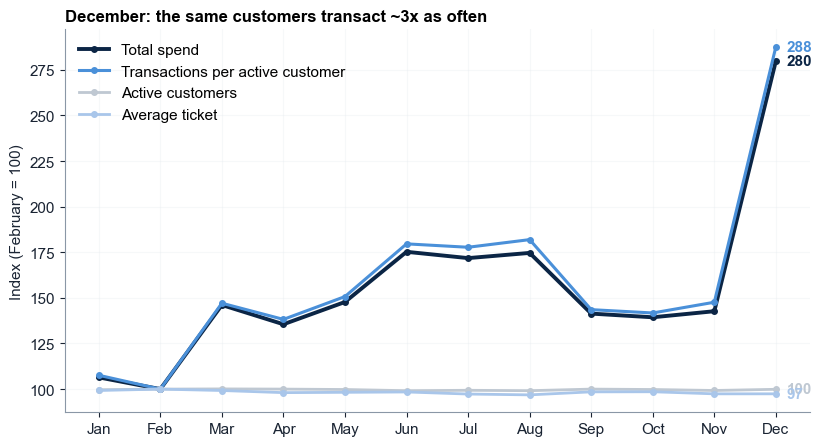

In [43]:
# Task 1 Q1: index vs February (trough)
active_m = txn.groupby("transaction_month").consumer_id.nunique()
idx = pd.DataFrame({"Total spend": by_month.total, "Transactions per active customer": by_month["count"] / active_m,
                    "Average ticket": by_month.avg_ticket, "Active customers": active_m})
idx = 100 * idx / idx.loc[trough]
fig, ax = plt.subplots(figsize=BIG)
for col, colr, lw in [("Total spend", NAVY, 2.8), ("Transactions per active customer", MID, 2.2),
                      ("Active customers", GRAY, 2), ("Average ticket", LIGHT, 2)]:
    ax.plot(MONTHS, idx[col], color=colr, lw=lw, marker="o", ms=4, label=col)
    ax.annotate(f"{idx[col].iloc[-1]:.0f}", (11, idx[col].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", color=colr, fontweight="bold")
ax.set(ylabel="Index (February = 100)", title="December: the same customers transact ~3x as often")
ax.legend(loc="upper left")
deck_save(fig, "deck_q1_index")

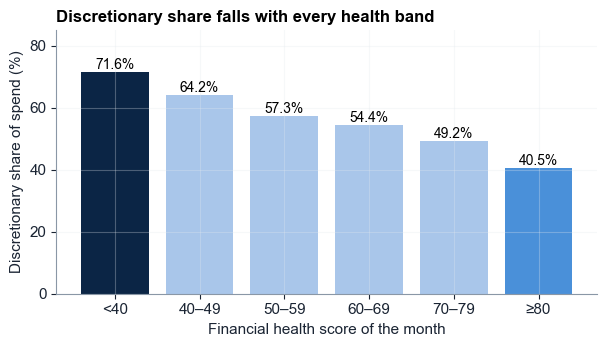

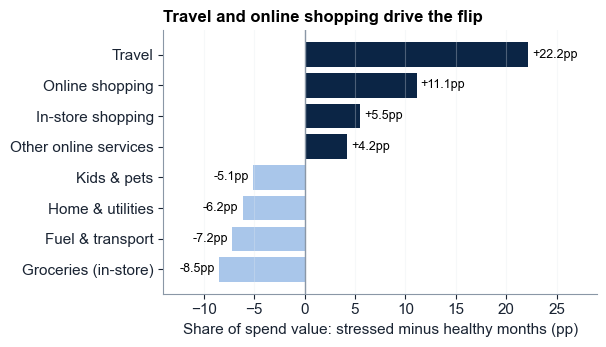

In [44]:
# Task 1 Q2: discretionary share by health band + category shift
b6 = pd.cut(mon.financial_health_score, [0, 40, 50, 60, 70, 80, 101], right=False, labels=["<40", "40–49", "50–59", "60–69", "70–79", "≥80"])
disc = mon.groupby(b6, observed=True).apply(lambda d: mix(d)["discretionary_%"], include_groups=False)
fig, ax = plt.subplots(figsize=HALF)
bars = ax.bar(disc.index.astype(str), disc.values, color=[NAVY] + [LIGHT] * 4 + [MID])
ax.bar_label(bars, fmt="%.1f%%", fontsize=10)
ax.set(ylim=(0, 85), ylabel="Discretionary share of spend (%)", xlabel="Financial health score of the month",
       title="Discretionary share falls with every health band")
deck_save(fig, "deck_q2_gradient")

share = lambda d: d.groupby("spending_category").spend_amount_vnd.sum() / d.spend_amount_vnd.sum() * 100
shift = (share(tm[tm.financial_health_score < 40]) - share(tm[tm.financial_health_score >= 80])).sort_values()
shift = pd.concat([shift.head(4), shift.tail(4)]).rename(index=EN_CAT)
fig, ax = plt.subplots(figsize=HALF)
ax.barh(shift.index, shift.values, color=[NAVY if v > 0 else LIGHT for v in shift.values])
for y, v in enumerate(shift.values):
    ax.text(v + (0.4 if v > 0 else -0.4), y, f"{v:+.1f}pp", va="center", ha="left" if v > 0 else "right", fontsize=9)
ax.axvline(0, color="#8A97A6", lw=1); ax.grid(axis="y", visible=False)
ax.set(xlim=(-14, 29), xlabel="Share of spend value: stressed minus healthy months (pp)", title="Travel and online shopping drive the flip")
deck_save(fig, "deck_q2_shift")

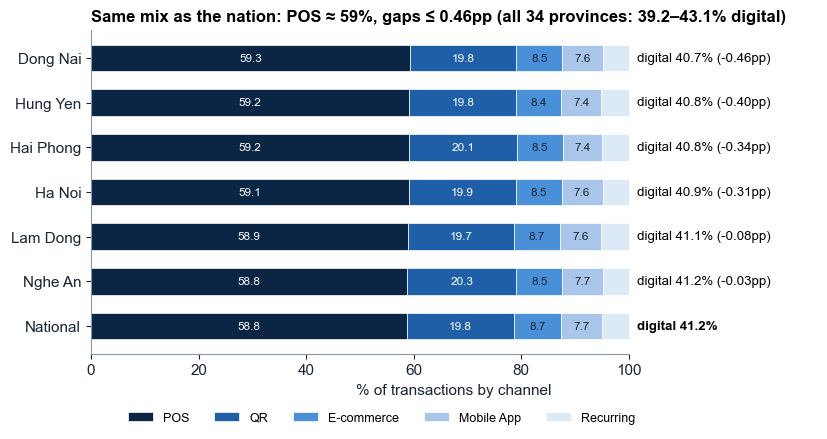

In [45]:
# Task 1 Q3: channel breakdown (POS vs four digital channels) of the six high-spend provinces vs national
mixp = by_count.rename(index=EN_PROV)
mixp = pd.concat([mixp.drop("National").loc[(gap_provinces["digital_%"] - national_digital).sort_values().rename(index=EN_PROV).index], mixp.loc[["National"]]])
fig, ax = plt.subplots(figsize=BIG)
left = np.zeros(len(mixp))
for ch, colr, lab in zip(channels, [NAVY, BLUE, MID, LIGHT, PALE], ["POS", "QR", "E-commerce", "Mobile App", "Recurring"]):
    ax.barh(mixp.index, mixp[ch], left=left, color=colr, height=0.6, label=lab, edgecolor="white", lw=0.5)
    for y_, (l_, v_) in enumerate(zip(left, mixp[ch])):
        if v_ > 6:
            ax.text(l_ + v_ / 2, y_, f"{v_:.1f}", ha="center", va="center", fontsize=8.5, color="white" if colr in (NAVY, BLUE) else INK)
    left += mixp[ch].values
for y_, n_ in enumerate(mixp.index):
    d_ = 100 - mixp.loc[n_, "POS"]
    ax.text(101.5, y_, f"digital {d_:.1f}%" + ("" if n_ == "National" else f" ({d_ - national_digital:+.2f}pp)"),
            va="center", fontsize=9.5, fontweight="bold" if n_ == "National" else "normal")
ax.invert_yaxis(); ax.grid(False); ax.spines["bottom"].set_bounds(0, 100)
ax.set(xlim=(0, 135), xticks=range(0, 101, 20), xlabel="% of transactions by channel",
       title=f"Same mix as the nation: POS ≈ 59%, gaps ≤ 0.46pp (all 34 provinces: {prov['digital_%'].min():.1f}–{prov['digital_%'].max():.1f}% digital)")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.4, -0.25), fontsize=9)
deck_save(fig, "deck_q3_gap")

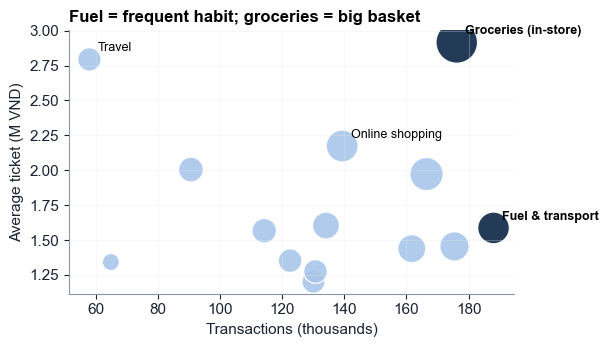

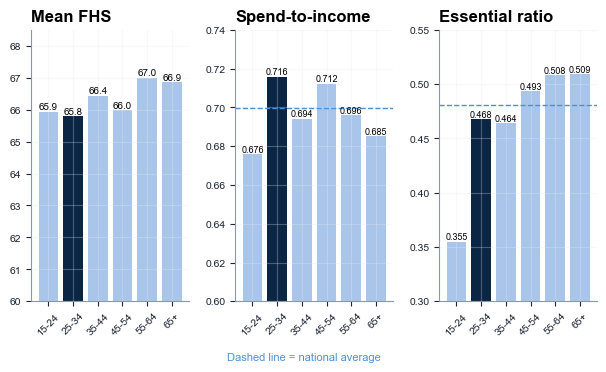

In [46]:
# Task 1 Q4 & Q5
c4 = cat.rename(index=EN_CAT)
fig, ax = plt.subplots(figsize=HALF)
key = ("Fuel & transport", "Groceries (in-store)")
colors = [NAVY if n in key else LIGHT for n in c4.index]
ax.scatter(c4["count"] / 1e3, c4.avg_ticket_m, s=c4.total / c4.total.max() * 900, c=colors, alpha=0.9, edgecolor="white")
for n, r in c4.iterrows():
    if n in key + ("Travel", "Online shopping"):
        ax.annotate(n, (r["count"] / 1e3, r.avg_ticket_m), xytext=(6, 6), textcoords="offset points", fontsize=9,
                    fontweight="bold" if n in key else "normal")
ax.set(xlabel="Transactions (thousands)", ylabel="Average ticket (M VND)", title="Fuel = frequent habit; groceries = big basket")
deck_save(fig, "deck_q4_categories")

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=HALF)
cc = [NAVY if str(c_) == "25-34" else LIGHT for c_ in cohorts.index]
b1 = a1.bar(cohorts.index.astype(str), cohorts.avg_fhs, color=cc); a1.bar_label(b1, fmt="%.1f", fontsize=7)
a1.set(ylim=(60, 68.5), title="Mean FHS")
b2 = a2.bar(cohorts.index.astype(str), cohorts.spend_to_income, color=cc); a2.bar_label(b2, fmt="%.3f", fontsize=6.5)
a2.axhline(mon.spend_to_income_ratio.mean(), color=MID, ls="--", lw=1)
a2.set(ylim=(0.6, 0.74), title="Spend-to-income")
b3 = a3.bar(cohorts.index.astype(str), cohorts.essential_ratio, color=cc); a3.bar_label(b3, fmt="%.3f", fontsize=6.5)
a3.axhline(mon.essential_spend_ratio.mean(), color=MID, ls="--", lw=1)
a3.set(ylim=(0.30, 0.55), title="Essential ratio")
for a_ in (a1, a2, a3):
    a_.tick_params(axis="x", labelsize=7.5, rotation=45); a_.tick_params(axis="y", labelsize=7.5); a_.title.set_fontsize(10)
fig.text(0.5, -0.02, "Dashed line = national average", ha="center", fontsize=8, color=MID)
deck_save(fig, "deck_q5_cohorts")

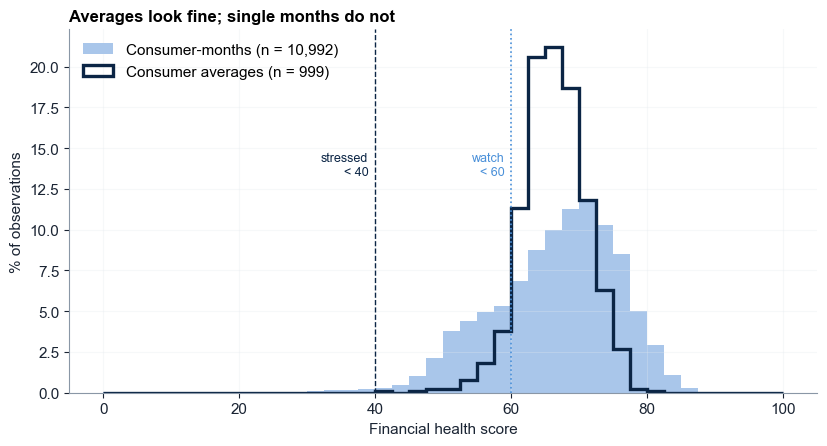

In [47]:
# Task 2 D1: consumer averages vs consumer-months
fig, ax = plt.subplots(figsize=BIG)
edges = np.arange(0, 101, 2.5)
ax.hist(mon.financial_health_score, edges, color=LIGHT, weights=np.full(len(mon), 100 / len(mon)), label="Consumer-months (n = 10,992)")
ax.hist(cons.fhs, edges, histtype="step", lw=2.4, color=NAVY, weights=np.full(len(cons), 100 / len(cons)), label="Consumer averages (n = 999)")
ax.axvline(40, color=NAVY, ls="--", lw=1); ax.axvline(60, color=MID, ls=":", lw=1.2)
top_y = ax.get_ylim()[1]
ax.text(39, top_y * 0.6, "stressed\n< 40", ha="right", color=NAVY, fontsize=9)
ax.text(59, top_y * 0.6, "watch\n< 60", ha="right", color=MID, fontsize=9)
ax.set(xlabel="Financial health score", ylabel="% of observations", title="Averages look fine; single months do not")
ax.legend(loc="upper left")
deck_save(fig, "deck_d1_distribution")

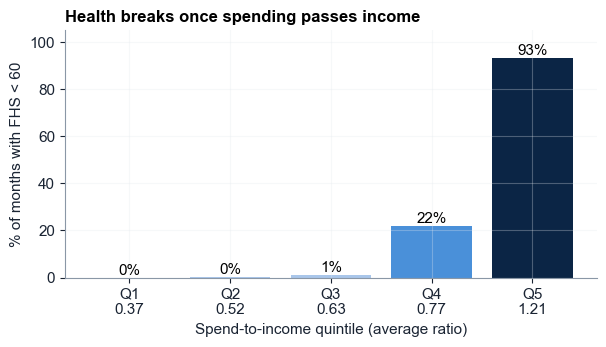

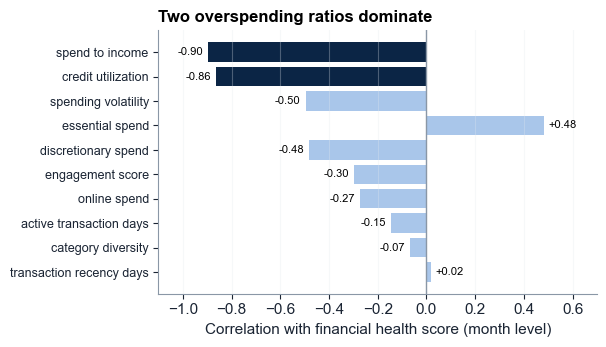

In [48]:
# Task 2 D2: threshold by spend-to-income quintile (month level) + correlations
qm = pd.qcut(mon.spend_to_income_ratio, 5, labels=False)
below = mon.groupby(qm).financial_health_score.apply(lambda s: 100 * (s < 60).mean())
avg_sti = mon.groupby(qm).spend_to_income_ratio.mean()
fig, ax = plt.subplots(figsize=HALF)
bars = ax.bar([f"Q{i + 1}\n{v:.2f}" for i, v in enumerate(avg_sti)], below.values, color=[LIGHT] * 3 + [MID, NAVY])
ax.bar_label(bars, fmt="%.0f%%")
ax.set(ylim=(0, 105), ylabel="% of months with FHS < 60", xlabel="Spend-to-income quintile (average ratio)",
       title="Health breaks once spending passes income")
deck_save(fig, "deck_d2_threshold")

cr = corr.drop("average_transaction_value_vnd", errors="ignore")
cr = cr.reindex(cr.abs().sort_values().index)
fig, ax = plt.subplots(figsize=HALF)
ax.barh([c_.replace("_", " ").replace(" ratio", "") for c_ in cr.index], cr.values,
        color=[NAVY if abs(v) > 0.8 else LIGHT for v in cr.values])
for y, v in enumerate(cr.values):
    ax.text(v + (0.02 if v > 0 else -0.02), y, f"{v:+.2f}", va="center", ha="left" if v > 0 else "right", fontsize=8)
ax.axvline(0, color="#8A97A6", lw=1); ax.grid(axis="y", visible=False); ax.tick_params(axis="y", labelsize=9)
ax.set(xlim=(-1.1, 0.7), xlabel="Correlation with financial health score (month level)", title="Two overspending ratios dominate")
deck_save(fig, "deck_d2_drivers")

                           As observed  Holding spend-to-income constant
Age cohort                         1.2                               1.7
Province (n ≥ 15)                  4.8                               1.6
Occupation group (n ≥ 20)          6.2                               1.3


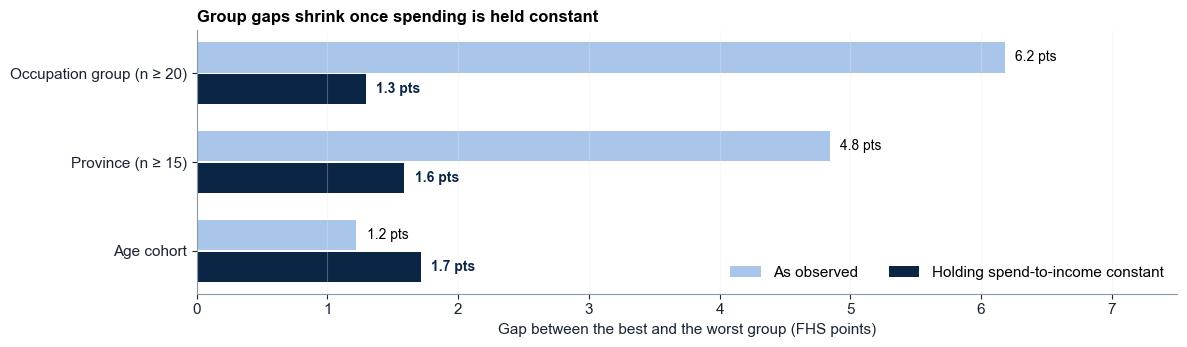

In [49]:
# Task 2 D3: group spread before and after holding spend-to-income constant
b_, a_ = np.polyfit(cons.spend_to_income_ratio, cons.fhs, 1)
cons["fhs_adj"] = cons.fhs - (a_ + b_ * cons.spend_to_income_ratio) + cons.fhs.mean()
def spread(col, minn):
    g = cons.groupby(col, observed=True).filter(lambda d: len(d) >= minn).groupby(col, observed=True)
    return g.fhs.mean().max() - g.fhs.mean().min(), g.fhs_adj.mean().max() - g.fhs_adj.mean().min()
dims = {"Age cohort": ("cohort", 1), "Province (n ≥ 15)": ("province", 15), "Occupation group (n ≥ 20)": ("occupation_group", 20)}
sp = pd.DataFrame({k: spread(c_, n) for k, (c_, n) in dims.items()}, index=["As observed", "Holding spend-to-income constant"]).T
print(sp.round(1))
fig, ax = plt.subplots(figsize=(12, 3.6))
y = np.arange(len(sp))
ax.barh(y + 0.18, sp["As observed"], 0.34, color=LIGHT, label="As observed")
ax.barh(y - 0.18, sp["Holding spend-to-income constant"], 0.34, color=NAVY, label="Holding spend-to-income constant")
for i, (o, a2_) in enumerate(sp.values):
    ax.text(o + 0.08, i + 0.18, f"{o:.1f} pts", va="center", fontsize=10)
    ax.text(a2_ + 0.08, i - 0.18, f"{a2_:.1f} pts", va="center", fontsize=10, color=NAVY, fontweight="bold")
ax.set_yticks(y, sp.index); ax.grid(axis="y", visible=False)
ax.set(xlim=(0, 7.5), xlabel="Gap between the best and the worst group (FHS points)", title="Group gaps shrink once spending is held constant")
ax.legend(loc="lower right", ncol=2)
deck_save(fig, "deck_d3_spread")

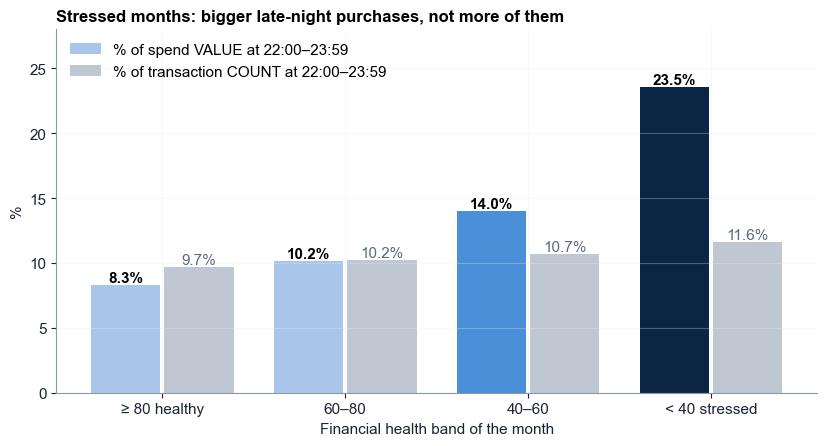

In [50]:
# Task 2 D4: late-night spend value vs count by health band
tm["band"] = pd.cut(tm.financial_health_score, [0, 40, 60, 80, 101], right=False, labels=["< 40 stressed", "40–60", "60–80", "≥ 80 healthy"])
tm["late"] = tm.transaction_hour >= 22
lv = tm.groupby("band", observed=True).apply(lambda d: 100 * d.loc[d.late, "spend_amount_vnd"].sum() / d.spend_amount_vnd.sum(), include_groups=False).iloc[::-1]
lc = (tm.groupby("band", observed=True).late.mean() * 100).iloc[::-1]
fig, ax = plt.subplots(figsize=BIG)
x = np.arange(len(lv))
b1 = ax.bar(x - 0.2, lv.values, 0.38, color=[LIGHT, LIGHT, MID, NAVY], label="% of spend VALUE at 22:00–23:59")
b2 = ax.bar(x + 0.2, lc.values, 0.38, color=GRAY, label="% of transaction COUNT at 22:00–23:59")
ax.bar_label(b1, fmt="%.1f%%", fontweight="bold"); ax.bar_label(b2, fmt="%.1f%%", color="#5B6B7B")
ax.set_xticks(x, lv.index.astype(str)); ax.set(ylim=(0, 28), xlabel="Financial health band of the month", ylabel="%",
                                                title="Stressed months: bigger late-night purchases, not more of them")
ax.legend(loc="upper left")
deck_save(fig, "deck_d4_latenight")

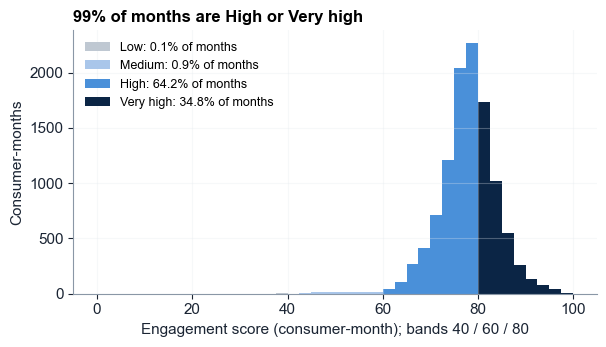

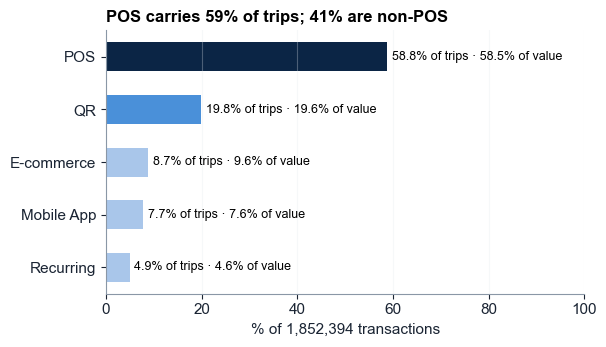

In [51]:
# Task 3 D1–D2: engagement histogram coloured by official band + channel mix
fig, ax = plt.subplots(figsize=HALF)
eb = np.arange(0, 101, 2.5)
for lo, hi, colr, lab in [(0, 40, GRAY, "Low"), (40, 60, LIGHT, "Medium"), (60, 80, MID, "High"), (80, 101, NAVY, "Very high")]:
    vals = mon.engagement_score[(mon.engagement_score >= lo) & (mon.engagement_score < hi)]
    ax.hist(vals, eb, color=colr, label=f"{lab}: {100 * len(vals) / len(mon):.1f}% of months")
ax.set(xlabel="Engagement score (consumer-month); bands 40 / 60 / 80", ylabel="Consumer-months", title="99% of months are High or Very high")
ax.legend(loc="upper left", fontsize=9)
deck_save(fig, "deck_t3_engagement")

chs = channel_share.rename(index={"QR Payment": "QR", "Recurring Payment": "Recurring"}).sort_values("% of transactions")
fig, ax = plt.subplots(figsize=HALF)
ax.barh(chs.index, chs["% of transactions"], color=[LIGHT, LIGHT, LIGHT, MID, NAVY], height=0.55)
for y_, (tr_, vl) in enumerate(chs[["% of transactions", "% of spend"]].values):
    ax.text(tr_ + 1, y_, f"{tr_:.1f}% of trips · {vl:.1f}% of value", va="center", fontsize=9)
ax.grid(axis="y", visible=False); ax.set(xlim=(0, 100), xlabel="% of 1,852,394 transactions", title="POS carries 59% of trips; 41% are non-POS")
deck_save(fig, "deck_t3_channels")

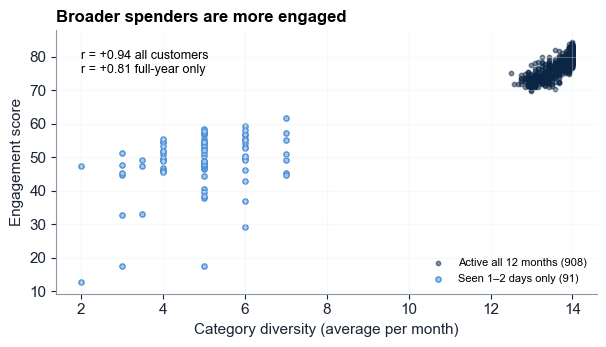

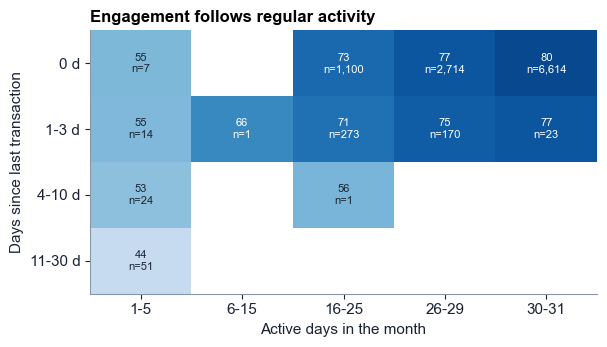

In [52]:
# Task 3 D3–D4: diversity vs engagement + recency x frequency heatmap
full_mask = (months_seen.reindex(cons_eng.index) == 12).values
fig, ax = plt.subplots(figsize=HALF)
ax.scatter(cons_eng.category_diversity[full_mask], cons_eng.engagement_score[full_mask], s=10, color=NAVY, alpha=0.5, label="Active all 12 months (908)")
ax.scatter(cons_eng.category_diversity[~full_mask], cons_eng.engagement_score[~full_mask], s=14, color=LIGHT, edgecolor=MID, label="Seen 1–2 days only (91)")
r_all = cons_eng.category_diversity.corr(cons_eng.engagement_score)
r_full = cons_eng[full_mask].category_diversity.corr(cons_eng[full_mask].engagement_score)
ax.text(2, 82, f"r = {r_all:+.2f} all customers\nr = {r_full:+.2f} full-year only", fontsize=9, va="top")
ax.set(xlabel="Category diversity (average per month)", ylabel="Engagement score", title="Broader spenders are more engaged")
ax.legend(loc="lower right", fontsize=8)
deck_save(fig, "deck_t3_diversity")

cnt = mon.pivot_table(index=recency_bin, columns=freq_bin, values="engagement_score", aggfunc="size", observed=False).reindex_like(heat)
fig, ax = plt.subplots(figsize=HALF)
ax.imshow(heat.values, cmap="Blues", vmin=30, vmax=85, aspect="auto")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v, n = heat.values[i, j], cnt.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}\nn={int(n):,}", ha="center", va="center", fontsize=8, color="white" if v > 65 else INK)
ax.set_xticks(range(heat.shape[1]), heat.columns); ax.set_yticks(range(heat.shape[0]), heat.index); ax.grid(False)
ax.set(xlabel="Active days in the month", ylabel="Days since last transaction", title="Engagement follows regular activity")
deck_save(fig, "deck_t3_heatmap")

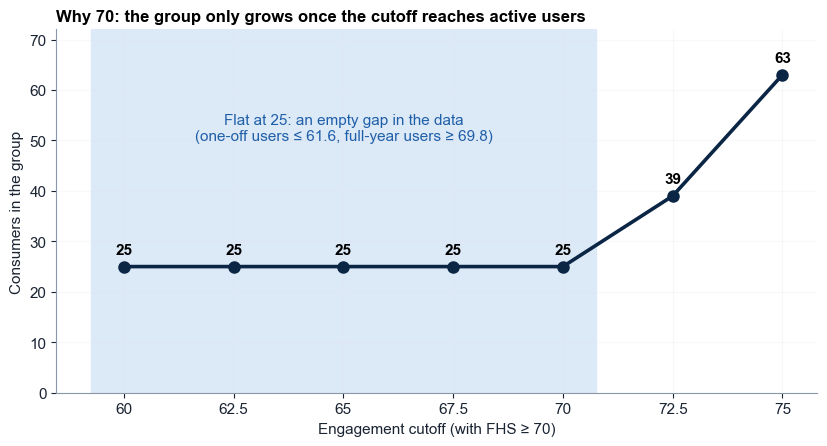

In [53]:
# Task 3 D5: group size vs engagement cutoff
cuts = [60, 62.5, 65, 67.5, 70, 72.5, 75]
sizes_c = [int(((fhs_c >= 70) & (eng_c < c_)).sum()) for c_ in cuts]
fig, ax = plt.subplots(figsize=BIG)
ax.plot([str(c_) for c_ in cuts], sizes_c, color=NAVY, lw=2.6, marker="o", ms=8)
for i, v in enumerate(sizes_c):
    ax.annotate(str(v), (i, v), xytext=(0, 9), textcoords="offset points", ha="center", fontweight="bold")
ax.axvspan(-0.3, 4.3, color=PALE, zorder=0)
ax.text(2, 50, "Flat at 25: an empty gap in the data\n(one-off users ≤ 61.6, full-year users ≥ 69.8)", ha="center", color=BLUE)
ax.set(ylim=(0, 72), xlabel="Engagement cutoff (with FHS ≥ 70)", ylabel="Consumers in the group",
       title="Why 70: the group only grows once the cutoff reaches active users")
deck_save(fig, "deck_t3_cutoff")

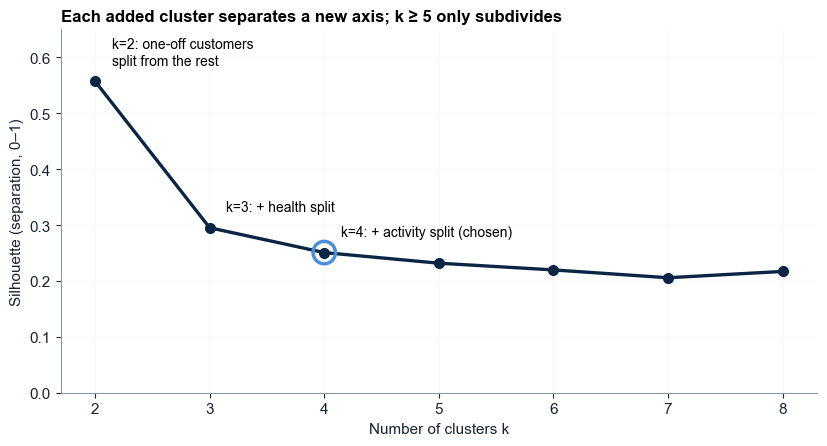

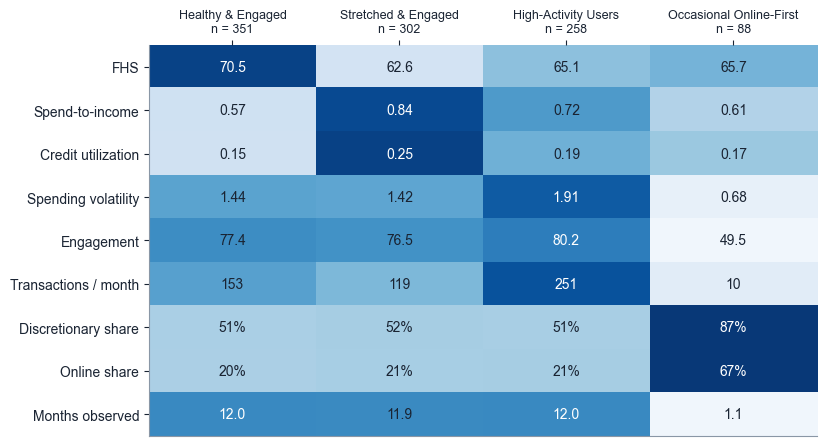

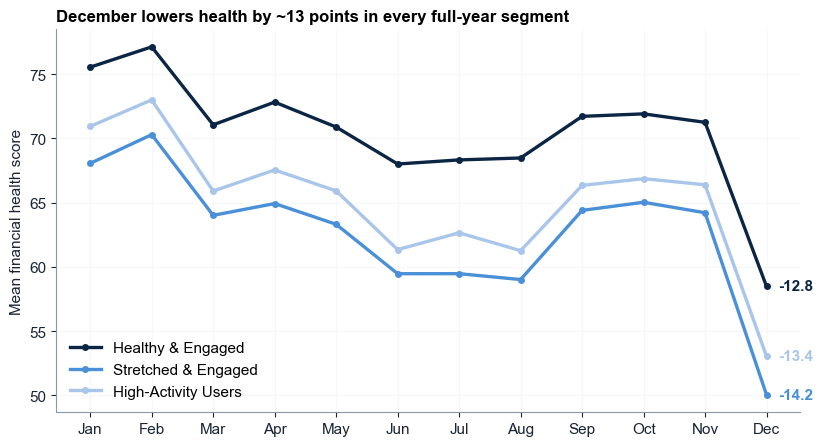

In [54]:
# Task 4: silhouette by k, profile heatmap, December effect
fig, ax = plt.subplots(figsize=BIG)
ax.plot(k_scores.index.astype(str), k_scores.silhouette, color=NAVY, lw=2.4, marker="o", ms=7)
ax.scatter(["4"], [k_scores.loc[4, "silhouette"]], s=260, facecolor="none", edgecolor=MID, lw=2.5, zorder=3)
for k, txt_ in {2: "k=2: one-off customers\nsplit from the rest", 3: "k=3: + health split", 4: "k=4: + activity split (chosen)"}.items():
    ax.annotate(txt_, (str(k), k_scores.loc[k, "silhouette"]), xytext=(12, 12), textcoords="offset points", fontsize=10)
ax.set(ylim=(0, 0.65), xlabel="Number of clusters k", ylabel="Silhouette (separation, 0–1)",
       title="Each added cluster separates a new axis; k ≥ 5 only subdivides")
deck_save(fig, "deck_t4_k")

order = ["Healthy & Engaged", "Stretched & Engaged", "High-Activity Users", "Occasional Online-First"]
prof_rows = pd.DataFrame({"FHS": summary.financial_health_score, "Spend-to-income": summary.spend_to_income_ratio,
                          "Credit utilization": summary.credit_utilization_ratio, "Spending volatility": summary.spending_volatility,
                          "Engagement": summary.engagement_score, "Transactions / month": summary.transaction_count,
                          "Discretionary share": summary.discretionary_spend_ratio * 100, "Online share": summary.online_spend_ratio * 100,
                          "Months observed": months_seen.groupby(seg.segment).mean()}).loc[order]
fmt = {"FHS": "{:.1f}", "Spend-to-income": "{:.2f}", "Credit utilization": "{:.2f}", "Spending volatility": "{:.2f}", "Engagement": "{:.1f}",
       "Transactions / month": "{:.0f}", "Discretionary share": "{:.0f}%", "Online share": "{:.0f}%", "Months observed": "{:.1f}"}
zz = (prof_rows - prof_rows.mean()) / prof_rows.std()
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.imshow(zz.T.values, cmap="Blues", vmin=-1.6, vmax=1.6, aspect="auto")
for i, col in enumerate(prof_rows.columns):
    for j, s_ in enumerate(order):
        ax.text(j, i, fmt[col].format(prof_rows.loc[s_, col]), ha="center", va="center", fontsize=10,
                color="white" if zz.loc[s_, col] > 0.5 else INK)
ax.set_xticks(range(4), [f"{s_}\nn = {int((seg.segment == s_).sum())}" for s_ in order], fontsize=9)
ax.set_yticks(range(len(prof_rows.columns)), prof_rows.columns, fontsize=10); ax.grid(False)
ax.xaxis.tick_top()
deck_save(fig, "deck_t4_profile")

fig, ax = plt.subplots(figsize=BIG)
for s_, colr in zip(order[:3], [NAVY, MID, LIGHT]):
    ax.plot(MONTHS, trend[s_], color=colr, lw=2.4, marker="o", ms=4, label=s_)
    ax.annotate(f"{trend[s_].iloc[-1] - trend[s_].iloc[-2]:+.1f}", (11, trend[s_].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color=colr, fontweight="bold")
ax.set(ylabel="Mean financial health score", title="December lowers health by ~13 points in every full-year segment")
ax.legend(loc="lower left")
deck_save(fig, "deck_t4_december")

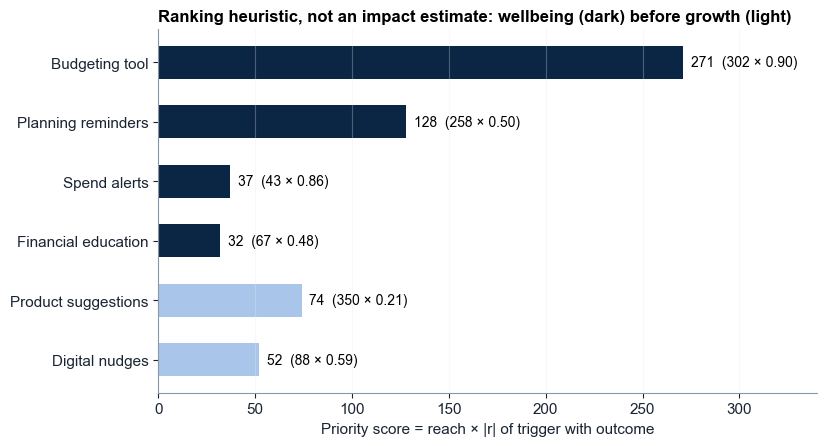

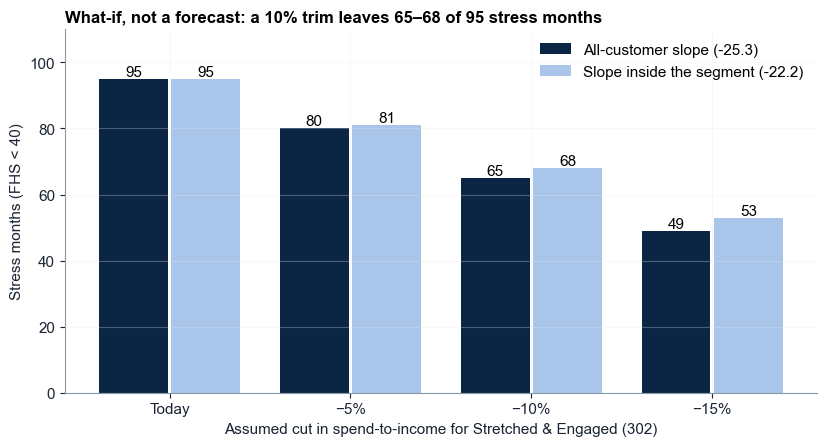

In [55]:
# Task 5: priority score and impact scenario
tg = targets.iloc[::-1]
fig, ax = plt.subplots(figsize=BIG)
ax.barh(tg.tool, tg.score, color=[NAVY if t_ == "wellbeing" else LIGHT for t_ in tg.track], height=0.55)
for y_, (sc_, rc_, dr_) in enumerate(tg[["score", "reach", "driver |r|"]].values):
    ax.text(sc_ + 4, y_, f"{sc_:.0f}  ({rc_:.0f} × {dr_:.2f})", va="center", fontsize=10)
ax.grid(axis="y", visible=False)
ax.set(xlim=(0, 340), xlabel="Priority score = reach × |r| of trigger with outcome", title="Ranking heuristic, not an impact estimate: wellbeing (dark) before growth (light)")
deck_save(fig, "deck_t5_priority")

cuts_s = [0, 0.05, 0.10, 0.15]
pooled = [int(((mon.financial_health_score - slope * mon.spend_to_income_ratio * c_ * in_stretched) < 40).sum()) for c_ in cuts_s]
within = [int(((mon.financial_health_score - slope_s * mon.spend_to_income_ratio * c_ * in_stretched) < 40).sum()) for c_ in cuts_s]
fig, ax = plt.subplots(figsize=BIG)
x = np.arange(4)
b1 = ax.bar(x - 0.2, pooled, 0.38, color=NAVY, label=f"All-customer slope ({slope:.1f})")
b2 = ax.bar(x + 0.2, within, 0.38, color=LIGHT, label=f"Slope inside the segment ({slope_s:.1f})")
ax.bar_label(b1); ax.bar_label(b2)
ax.set_xticks(x, ["Today", "−5%", "−10%", "−15%"])
ax.set(ylim=(0, 110), xlabel="Assumed cut in spend-to-income for Stretched & Engaged (302)",
       ylabel="Stress months (FHS < 40)", title="What-if, not a forecast: a 10% trim leaves 65–68 of 95 stress months")
ax.legend(loc="upper right")
deck_save(fig, "deck_t5_scenario")

### Supporting numbers quoted on the slides
Numbers that appear on the slides but are not printed in the sections above.

In [56]:
from scipy.stats import f_oneway, binomtest
print("== Task 1")
no_travel = tm[tm.spending_category != "Du lịch"]
for name, d in [("stressed", no_travel[no_travel.financial_health_score < 40]), ("healthy", no_travel[no_travel.financial_health_score >= 80])]:
    print(f"  essential share of value without travel, {name}: {100 * d.loc[d.essential_spending_flag.astype(bool), 'spend_amount_vnd'].sum() / d.spend_amount_vnd.sum():.0f}%")
cust_dig = txn.groupby("consumer_id").digital.mean() * 100
print(f"  customer digital share p10-p90: {cust_dig.quantile(.1):.1f}-{cust_dig.quantile(.9):.1f}% ({cust_dig.quantile(.9) - cust_dig.quantile(.1):.1f}pp) "
      f"vs province range {prov['digital_%'].max() - prov['digital_%'].min():.1f}pp")
sig = [binomtest(int(prov.loc[p_, "digital"] * prov.loc[p_, "txns"]), int(prov.loc[p_, "txns"]), national_digital / 100).pvalue < 0.05 for p_ in gap_provinces.index]
print(f"  high-spend provinces with a significant gap (p < 0.05): {sum(sig)} of {len(sig)}")
print(f"  ANOVA of customer FHS across age cohorts: p = {f_oneway(*[g.fhs.values for _, g in cons.groupby('cohort', observed=True)]).pvalue:.2f}")

print("== Task 2")
dips = mon[mon.financial_health_score < 60].consumer_id.nunique()
print(f"  customers below 60 at least once: {dips} ({100 * dips / 999:.0f}%)")
print(f"  stressed months in January + December: {stressed.month.isin([1, 12]).sum()} of {len(stressed)}")
print(f"  stressed months spending more than income: {100 * (stressed.spend_to_income_ratio > 1).mean():.0f}%")
Xr = np.column_stack([mon.spend_to_income_ratio, mon.credit_utilization_ratio, np.ones(len(mon))])
coef, *_ = np.linalg.lstsq(Xr, mon.financial_health_score, rcond=None)
r2 = 1 - ((mon.financial_health_score - Xr @ coef) ** 2).sum() / ((mon.financial_health_score - mon.financial_health_score.mean()) ** 2).sum()
print(f"  R² of FHS on spend-to-income + utilization: {r2:.2f}; r between the two ratios: {mon.spend_to_income_ratio.corr(mon.credit_utilization_ratio):.2f}")
print(f"  ANOVA of customer FHS across provinces (n ≥ 15): p = {f_oneway(*[g.fhs.values for _, g in cons.groupby('province') if len(g) >= 15]).pvalue:.3f}")
cx_months = stressed.consumer_id.isin(crossover.consumer_id.unique())
print(f"  stress months held by the 43 crossover customers: {cx_months.sum()} of {len(stressed)} ({100 * cx_months.mean():.0f}%)")

print("== Task 3")
print(f"  customers using all five channels: {(txn.groupby('consumer_id').transaction_channel.nunique() == 5).sum()}")
fy = cons_eng[full_mask]
for c_ in ["active_transaction_days", "transaction_count", "transaction_recency_days"]:
    print(f"  full-year customers, r({c_}, engagement) = {fy[c_].corr(fy.engagement_score):+.2f}")
dorm = cons_eng.loc[healthy_disengaged.index]
last_month = mon[mon.consumer_id.isin(dorm.index)].groupby("consumer_id").month.max()
rest = cons_eng.drop(dorm.index)
print(f"  healthy-but-disengaged last seen Jan–Jul: {(last_month <= 7).sum()} of {len(dorm)}")
print(f"  age {demo.loc[dorm.index, 'age'].mean():.0f} vs {demo.drop(dorm.index).age.mean():.0f}; "
      f"spend-to-income {dorm.spend_to_income_ratio.mean():.2f} vs {rest.spend_to_income_ratio.mean():.2f}")

print("== Task 4")
stress_any = mon.assign(s=mon.financial_health_score < 40).groupby("consumer_id").s.any()
print("  had a stress month (%):", (100 * stress_any.groupby(seg.segment).mean()).round(1).to_dict())
no_dec = mon[mon.month != 12].groupby("consumer_id")[features].mean()  # 9 customers appear only in December
ari_nd = adjusted_rand_score(seg.loc[no_dec.index, "cluster"], KMeans(4, n_init=25, random_state=42).fit_predict(StandardScaler().fit_transform(no_dec)))
print(f"  ARI when December is dropped ({len(no_dec)} customers): {ari_nd:.3f}")
def cramers_v(a, b):
    tab = pd.crosstab(a, b); chi2 = chi2_contingency(tab)[0]
    return np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
print(f"  Cramér's V segment × age group {cramers_v(profiled.segment, age_group):.2f}, × gender {cramers_v(profiled.segment, profiled.gender):.2f}")

print("== Task 5 evidence")
print(f"  low health & low engagement (67): discretionary {100 * distress_tail.discretionary_spend_ratio.mean():.0f}% vs base {100 * seg.discretionary_spend_ratio.mean():.0f}%")
occ_tx = txn[txn.consumer_id.isin(seg.index[seg.segment == "Occasional Online-First"])]
print(f"  Occasional Online-First: {100 * occ_tx.loc[occ_tx.transaction_channel.isin(['E-commerce', 'Mobile App']), 'spend_amount_vnd'].sum() / occ_tx.spend_amount_vnd.sum():.1f}% of spend via e-commerce + mobile app")
print("== Task 5 fairness (target groups vs base)")
groups = {"Reminders (High-Activity)": seg.index[seg.segment == "High-Activity Users"], "Education (low health & engagement)": distress_tail.index,
          "Nudges (Occasional)": seg.index[seg.segment == "Occasional Online-First"]}
female = lambda idx: 100 * (demo.loc[idx, "gender"] == "Nữ").mean()
print(f"  base: female {female(demo.index):.1f}%, mean age {demo.age.mean():.1f}")
for k, idx in groups.items():
    print(f"  {k}: female {female(idx):.1f}%, mean age {demo.loc[idx, 'age'].mean():.1f}")

== Task 1
  essential share of value without travel, stressed: 37%
  essential share of value without travel, healthy: 60%


  customer digital share p10-p90: 37.2-45.9% (8.6pp) vs province range 3.9pp
  high-spend provinces with a significant gap (p < 0.05): 3 of 6
  ANOVA of customer FHS across age cohorts: p = 0.13
== Task 2
  customers below 60 at least once: 869 (87%)
  stressed months in January + December: 46 of 95
  stressed months spending more than income: 98%
  R² of FHS on spend-to-income + utilization: 0.82; r between the two ratios: 0.90
  ANOVA of customer FHS across provinces (n ≥ 15): p = 0.009
  stress months held by the 43 crossover customers: 67 of 95 (71%)
== Task 3


  customers using all five channels: 925
  full-year customers, r(active_transaction_days, engagement) = +0.80
  full-year customers, r(transaction_count, engagement) = +0.76
  full-year customers, r(transaction_recency_days, engagement) = -0.58
  healthy-but-disengaged last seen Jan–Jul: 19 of 25
  age 61 vs 50; spend-to-income 0.46 vs 0.70
== Task 4
  had a stress month (%): {'Healthy & Engaged': 1.7, 'High-Activity Users': 0.8, 'Occasional Online-First': 1.1, 'Stretched & Engaged': 20.2}
  ARI when December is dropped (990 customers): 0.873
  Cramér's V segment × age group 0.23, × gender 0.13
== Task 5 evidence
  low health & low engagement (67): discretionary 86% vs base 55%


  Occasional Online-First: 60.6% of spend via e-commerce + mobile app
== Task 5 fairness (target groups vs base)
  base: female 50.6%, mean age 50.1
  Reminders (High-Activity): female 60.5%, mean age 43.2
  Education (low health & engagement): female 47.8%, mean age 57.7
  Nudges (Occasional): female 47.7%, mean age 57.9
